# Проект. Исследование стартапов

Автор: Козлачкова Светлана

Дата: 10.12.2025 год.

## Введение

**Цель проекта**: Оказание аналитической поддержки финансовой компании в разработке инвестиционных стратегий. Исследование направлено на выявление ключевых закономерностей финансирования стартапов на основе исторических данных для оценки перспектив входа на рынок через покупку и развитие компаний.

**Основные этапы проекта**:
1. **Предобработка данных** - Предобработка и очистка исходных данных.
2. **Сравнительный анализ** - Группировка компаний по срокам финансирования и сравнение групп по количеству и объему инвестиций.
3. **Сегментация рынка** -  Классификация рыночных сегментов на массовые, средние и нишевые.
4. **Оценка объемов финансирования** - Определение типичных и аномальных (выбросов) объемов инвестиций.
5. **Анализ типов финансирования** - Сравнение популярности и общего объема различных типов инвестиций.
6. **Динамика рынка** - Изучение активности рынка (количества раундов) и объемов инвестиций в годовой динамике.
7. **Анализ возврата инвестиций** - Расчет и оценка устойчивости доли возвращенных средств для различных типов финансирования.
8. **Итоговые рекомендации**: - Подведение итогов и выработка рекомендаций для инвестиционной стратегии на 2015 год.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.



### 1.1. Вывод общей информации

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import sys

from datetime import datetime

In [2]:
pd.options.display.max_columns = 55

In [3]:
np.set_printoptions(threshold=sys.maxsize)

In [4]:
pd.set_option('display.float_format', '{:.2f}'.format)

Для начала создадим датафрейм `invest`, куда выгрузим данные из датасета `/cb_investments.csv`.

In [5]:
# выгружаем данные из датасета /datasets/cb_investments.csv` в датафрейм invest
invest = pd.read_csv('https://code.s3.yandex.net/datasets/cb_investments.zip', sep = ';', low_memory = False)

Познакомимся с данными датафрейма **`invest`** - выведем случайные 10 строк методом `sample()`, и информацию о датафрейме методом `info()`

In [6]:
# Выведем случайные 10 строк датафрейма invest
invest.sample(10, random_state = 321)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
6819,That's Us Technologies,http://thatsus.com,|Advertising|,Advertising,"5,75,000",operating,USA,FL,Tampa,Tampa,1.00,0.00,2003-01-01,2003-01,2003-Q1,2003.00,2012-11-27,2012-11-27,2012-11-27,575000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
19205,Cameron & Wilding,http://cameronandwilding.com,|Web Development|Web CMS|Internet|Content|Cons...,Content,"16,567",operating,GBR,NaN,London,London,1.00,0.00,2010-01-01,2010-01,2010-Q1,2010.00,2009-12-01,2009-12-01,2009-12-01,16567.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
42965,Grabbed,http://www.grabbed.com.au,|Coupons|Group Buying|Advertising|,Advertising,"20,000",operating,AUS,NaN,Sydney,Surry Hills,1.00,0.00,NaN,NaN,NaN,NaN,2011-02-01,2011-02-01,2011-02-01,20000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
9537,"Shenzhen Fortuna Technology Co.,Ltd",http://www.aliexpress.com/store/414174,|E-Commerce|,E-Commerce,-,operating,NaN,NaN,NaN,NaN,1.00,0.00,2005-09-01,2005-09,2005-Q3,2005.00,2005-09-01,2005-09-01,2005-09-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
23492,Montiel USA,http://montiel.com,NaN,NaN,"8,27,500",operating,USA,CA,San Diego,San Diego,1.00,0.00,2011-01-01,2011-01,2011-Q1,2011.00,2011-10-25,2011-10-25,2011-10-25,0.00,827500.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6478,Jiglu,http://www.jiglu.com,|Collaboration|SEO|Software|,Software,"8,00,000",operating,GBR,NaN,London,London,1.00,1.00,2003-01-01,2003-01,2003-Q1,2003.00,2007-08-01,2007-08-01,2007-08-01,0.00,0.00,0.00,0.00,0.00,0.00,800000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
22116,RewardMe,http://RewardMe.com,|Tablets|Mobile|Incentives|Loyalty Programs|Ad...,Advertising,"11,00,000",operating,USA,CA,SF Bay Area,Mountain View,1.00,2.00,2010-08-01,2010-08,2010-Q3,2010.00,2011-05-01,2011-05-01,2011-05-01,0.00,0.00,0.00,0.00,0.00,0.00,1100000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
40140,Picwing,http://www.picwing.com,|Photo Sharing|Photography|,Photo Sharing,-,operating,USA,CA,SF Bay Area,San Francisco,1.00,1.00,NaN,NaN,NaN,NaN,2008-01-01,2008-01-01,2008-01-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
44010,Envision Healthcare,http://www.envisionhealthcare.com,|Hospitals|,Hospitals,"78,13,10,880",closed,USA,CO,Denver,Greenwood Village,2.00,0.00,NaN,NaN,NaN,NaN,2011-11-10,2011-11-10,2014-06-18,0.00,31310880.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,750000000.00,0.00,0.00,0.00,31310880.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3531,Blu Sky,http://www.bluscs.com,|Education|Software|,Software,-,operating,USA,WA,Seattle,Bellingham,2.00,NaN,1999-01-01,1999-01,1999-Q1,1999.00,2012-07-03,NaN,2012-07-03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [7]:
#Выведем информацию о датафрейме invest
invest_start = invest.shape
invest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Датафрейм **`invest`** состоит из 54294 строк и 40 столбцов.
Названия столбцов в целом соответствуют содержимому данных. Применяется стиль написания, близкий к `snake_case`, однако имеются отклонения: присутствуют заглавные буквы, а также лишние пробелы в начале и конце некоторых наименований. Во всех столбцах датафрейма есть пропуски. Максимальное количество заполненных строк в столбцах - 49438, это может говорить о том, что в датафрейме встречаются полностью пустые строки.
Датафрейм состоит из двух типов данных - `float64` и `object`. 

- Столбец `funding_total_usd` отображает общий объём привлечённых инвестиций в долларах США. Он имеет некорректный тип данных `object`, поскольку значения хранятся в виде строк с разделителями разрядов (запятыми), что препятствует математическим операциям. Требуется преобразование в числовой формат.
- Столбцы `funding_rounds` и `participants`, предназначены для хранения целого числа раундов финансирования и числа участников были ошибочно загружены с типом данных `float64`. Для обеспечения корректности данных и возможности дальнейшего анализа требуется преобразовать их в целочисленный тип `int`.
- Столбцы, содержащие информацию о датах - `founded_at`, `first_funding_at`, `mid_funding_at` и `last_funding_at`, представлены в строковом формате и имеют тип данных `object`. Для унификации и облегчения последующего анализа этих данных целесообразно преобразовать их к типу `datetime`.
- Столбец `founded_year`, содержащий данные о годах основания компаний, в настоящее время имеет тип `float64`. Для корректного представления целочисленных значений (годов) его следует преобразовать к типу `int`.

Далее создадим датафрейм returns, куда выгрузим данные из датасета \cb_returns.csv. Столбец year сделаем индексом датафрейма.

In [8]:
# выгружаем данные из датасета /datasets/cb_returns.csv в датафрейм returns
returns = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv', index_col = 'year')

In [9]:
# Посмотрим на датафрейм returns
returns

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.00,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.00,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.00,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.00,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.00,2.19,3.38,0.00,0.55,0.00
2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.00,2.40,3.51,0.00,0.05,0.00
2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.00,16.67,20.58,0.00,0.12,0.00
2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.00,88.81,24.36,0.00,0.57,0.00
2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.00,130.38,84.28,0.00,0.47,0.00


In [10]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


Датафрейм returns состоит из 15 строк и 12 столбцов. Названия столбцов в целом соответствуют содержимому данных и приведены к единому стилю. Пропусков в датафрейме не обнаружено. Тип данных для датафрейма выбран правильно.

### 1.2. Предобработка данных

В начале мы приведем наpзвания всех столбцов в датафрейме invest к единому стилю и уберем лишние пропуски в начале и конце строки.

In [11]:
# Преобразуем названия колонок датафрейма invest к единоиу стилю
invest.columns = invest.columns.str.lower().str.strip()
invest.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')

Найдем в датафрейме invest полностью пустые строки и удалим их

In [12]:
# Проверим количество полностью пустых столбцов
invest[invest.isna().all(axis=1)].shape[0]

4856

In [13]:
#Удалим полностью пустые строки
invest.dropna(axis = 0, how ='all', inplace = True)

In [14]:
# Проверим количество строк, оставшихся после удаления пустых строк
invest.shape[0]

49438

В столбце `funding_total_usd` необходимо удалить разделители разрядов (запятые) и преобразовать данные в числовой формат.

In [15]:
# Удаляем разделители разрядов - запятые
invest['funding_total_usd'] = invest['funding_total_usd'].str.replace(',', '').str.strip()

In [16]:
# Преобразуем столбец funding_total_usd к типу данных float
invest['funding_total_usd'] = pd.to_numeric(invest['funding_total_usd'], errors = 'coerce')

Далее мы займемся преобразованием типа данных в столбце founded_at, где хранится дата основания компании. В столбце присутствуют даты, выходящие за поддерживаемый типом datetime64 временной диапазон. При преобразовании к этому типу данных будет использован аргумент errors='coerce', который автоматически заменит все некорректные или выходящие за пределы диапазона значения на NaT (Not a Time). Важно отметить, что в наборе данных также присутствуют вспомогательные столбцы (founded_month, founded_quarter, founded_year), которые содержат различные производные данные, базирующиеся на основной дате из founded_at. При этом, что важно, во вспомогательных колонках встречаются пропущенные значения даже в тех случаях, когда основная дата в founded_at заполнена. Чтобы минимизировать потерю данных при последующем преобразовании в тип datetime64, мы сначала заполним пропуски во вспомогательных столбцах соответствующими значениями.

In [17]:
# Проверим пропуски вспомогательны столбцов относительно данных в founded_at
invest[['founded_at', 'founded_month', 'founded_quarter', 'founded_year']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 49438 entries, 0 to 49437
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   founded_at       38554 non-null  object 
 1   founded_month    38482 non-null  object 
 2   founded_quarter  38482 non-null  object 
 3   founded_year     38554 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.9+ MB


In [18]:
# Заполним столбец founded_year данными из столбца founded_at
def fill_year(row):
    if pd.notna(row['founded_at']):
        return datetime.strptime(row['founded_at'], '%Y-%m-%d').year
    else:
        return np.nan

invest['founded_year'] = invest.apply(fill_year, axis = 1)

In [19]:
# Преобразуем столбец founded_year к типу int
invest['founded_year'] = invest['founded_year'].astype('Int16')

In [20]:
# Заполним столбец founded_month данными из столбца founded_at
def fill_month(row):
    if pd.notna(row['founded_at']):
        dt1 = datetime.strptime(row['founded_at'], '%Y-%m-%d')
        return  dt1.strftime('%Y-%m')
    else:
        return np.nan

invest['founded_month'] = invest.apply(fill_month, axis = 1)

In [21]:
# Заполним столбец founded_quarter данными из столбца founded_at
def fill_quarter(row):
    quartal = {1:"Q1", 2:"Q1", 3:"Q1", 4:"Q2", 5:"Q2", 6:"Q2", 7:"Q3", 8:"Q3", 9:"Q3", 10:"Q4", 11:"Q4", 12:"Q4"}
    if pd.notna(row['founded_at']):
        dt1 = datetime.strptime(row['founded_at'], '%Y-%m-%d')
        return  f'{dt1.year}-{quartal[dt1.month]}'
    else:
        return np.nan

invest['founded_quarter'] = invest.apply(fill_quarter, axis = 1)

In [22]:
#Преобразуем столбец 'founded_at' к типу datetime64
invest['founded_at'] = pd.to_datetime(invest['founded_at'], format = '%Y-%m-%d', errors = 'coerce')

Преобразуем столбцы `first_funding_at`, `mid_funding_at` и `last_funding_at` хранящие даты первого, среднего и последнего финансирования к типу данных `datetime64`.

In [23]:
# Преобразуем столбцы first_funding_at, mid_funding_at и last_funding_at к типу данных datetime64.
fin_columns = ['first_funding_at','mid_funding_at','last_funding_at']
for col in fin_columns:
    invest[col] = pd.to_datetime(invest[col], format = '%Y-%m-%d', errors = 'coerce')

Преобразуем столбцы `funding_rounds` и `participants` к типу данных int

In [24]:
# Проверим уникальные значения в столбце funding_rounds
invest['funding_rounds'].sort_values().unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 18.])

In [25]:
# Проверим уникальные значения в столбце participants
invest['participants'].sort_values().unique()

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 32., 36., nan])

Диапазоны значений в столбцах `funding_rounds` (от 1 до 18) и `participants` (от 0 до 36) невелики. Учитывая эти ограничения, для хранения данных в обоих столбцах будет достаточно типа данных Int8.

In [26]:
int_columns = ['funding_rounds','participants']
for col in int_columns:
    invest[col] = invest[col].astype('Int8')

Приступим к обработке текстовых столбцов. В качестве первого шага мы унифицируем их формат: приведем все значения к нижнему регистру и удалим начальные/конечные пробелы в каждой строке

In [27]:
text_columns = ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']

for column in text_columns:
    invest[column] = invest[column].str.lower().str.strip()

Далее обработаем пропуски данных в текстовых столбцах. Посмотрим долю пропущенных значений в текстовых столбцах

In [28]:
# Проверим пропуски в столбцах с типом данных object
invest_text = invest.select_dtypes(include=['object'])
pd.DataFrame(round(invest_text.isna().mean()* 100,2)).style.background_gradient('coolwarm')

,0
name,0.000000
homepage_url,6.980000
category_list,8.010000
market,8.010000
status,2.660000
country_code,10.670000
state_code,38.990000
region,10.670000
city,12.370000
founded_month,22.020000


В столбце `name` пропушено всего лишь одно значение, посмотрим какое

In [29]:
# Проверяем пропущенное значение в столбце name
invest[invest['name'].isna()]

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
27212,NaN,http://tellitin10.com,|startups|,startups,25000.00,closed,NaN,NaN,NaN,NaN,1,<NA>,2011-10-01,2011-10,2011-Q4,2011,2012-03-01,NaT,2012-03-01,25000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [30]:
# Заменим пропущенное название стартапа доменным именем из столбца homepade_url
invest.loc[27212,'name'] = 'tellitin10'

В остальных столбцах мы не сможем корректно заполнить пропуски, поэтому заполним его значением-индикатором `unknown`.

In [31]:
text_columns1 = ['homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']
for column in text_columns1:
    invest[column] = invest[column].fillna('unknown')

Проверим данные на наличие явных и неявных дубликатов. Поиск неявных дубликатов будет производиться путем анализа комбинаций значений в столбцах `name`, `funding_total_usd`, `country_code` и `city`.

In [32]:
# Проверим данные на явные дубликаты
int(invest.duplicated().sum())

0

In [33]:
# Проверим данные на неявные дубликаты
dup = invest[invest.duplicated(subset = ['name', 'funding_total_usd', 'country_code', 'city'], keep=False)].sort_values('name')
dup

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
33038,busportal,http://www.busportal.pe,|comparison shopping|e-commerce|transportation...,e-commerce,250000.00,operating,per,unknown,lima,lima,2,<NA>,2012-12-31,2012-12,2012-Q4,2012,2013-12-03,NaT,2014-09-08,0.00,0.00,0.00,0.00,0.00,0.00,200000.00,50000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
33039,busportal,http://www.busportal.pe,|e-commerce|transportation|travel|,transportation,250000.00,operating,per,unknown,lima,lima,2,<NA>,2012-12-31,2012-12,2012-Q4,2012,2013-12-05,NaT,2014-09-12,0.00,0.00,0.00,0.00,0.00,0.00,200000.00,50000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
21003,cue,http://cue.me,|biotechnology|,biotechnology,7500000.00,operating,usa,ca,san diego,san diego,1,9,2010-01-01,2010-01,2010-Q1,2010,2014-11-18,2010-08-31,2014-11-18,0.00,7500000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7500000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
49370,cue,http://cue.me,unknown,unknown,7500000.00,operating,usa,ca,san diego,san diego,1,9,NaT,NaN,NaN,<NA>,2014-11-18,2010-08-31,2014-11-18,0.00,7500000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7500000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
44111,gain fitness,http://gainfitness.com,|fitness|health and wellness|,health and wellness,2790000.00,operating,usa,ca,sf bay area,san francisco,2,5,NaT,NaN,NaN,<NA>,2011-12-09,2011-12-09,2013-11-06,650000.00,2140000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
44112,gain fitness,http://gainfitness.com,|health and wellness|,health and wellness,2790000.00,operating,usa,ca,sf bay area,san francisco,2,5,NaT,NaN,NaN,<NA>,2011-12-09,2011-12-09,2013-11-06,650000.00,0.00,0.00,0.00,0.00,0.00,2140000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
21434,inmarket,http://www.inmarket.com,|apps|hardware|shopping|retail|online reservat...,mobile,1000000.00,operating,usa,ca,los angeles,los angeles,1,2,2010-04-01,2010-04,2010-Q2,2010,2010-05-01,2010-08-01,2010-05-01,0.00,1000000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1000000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
21444,inmarket,http://www.inmarket.com,|mobile shopping|advertising|retail|shopping|m...,mobile,1000000.00,operating,usa,ca,los angeles,los angeles,1,2,2010-04-01,2010-04,2010-Q2,2010,2010-08-01,2010-08-01,2010-08-01,0.00,1000000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1000000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
46258,moni,http://moni.com.ar/,|personal finance|,personal finance,NaN,unknown,unknown,unknown,unknown,unknown,1,<NA>,NaT,NaN,NaN,<NA>,2013-06-01,NaT,2013-06-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
46259,moni,http://www.moni.to,unknown,unknown,NaN,operating,unknown,unknown,unknown,unknown,1,<NA>,NaT,NaN,NaN,<NA>,2013-06-01,NaT,2013-06-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Были обнаружены данные по 8 компаниям, которые предположительно являются дубликатами.
- **busportal** небольшие расхождения в датах первого и последнего финансирования — разница составляет всего несколько дней, удалим строку с меньшим индексом;
- **cue** - оставим строку, где есть больше информации (в столбце `founded_at`);
- **gain fitness** - инвестиции в размере 2,14 млн долларов в одной записи отнесены к венчурным, а в другой — к инвестициям бизнес-ангелов. Поскольку сумма является значительной, мы отдаем приоритет строке, где эти инвестиции классифицируются как `venture`;
- **inmarket** - строки отличаются датами первой и последней инвестиций. Однако, поскольку среднее значение даты (2010-08-01) совпадает для обеих записей, более реалистичной представляется строка, где и начальная, и конечная даты инвестиций указаны как 2010-08-01;
- **moni** - не имеет данных по суммам инвестиций, поэтому на данном этапе оставим обе строки;
- **prestigos** - отличается только названием домена, удалим любую из них;
- **quest app** отличаются годами основания и категориями, скорее всего эти строки не являются дубликатами, оставим обе;
- **treasure valley urology services** - cтроки отличаются датами первой и последней инвестиций. При этом, ориентируясь на среднюю дату инвестиций (2010-01-14), более достоверной представляется запись с расширенным временным интервалом: датой первой инвестиции 2009-09-09 и датой последней — 2014-05-05.

In [34]:
# Создадим список со значениями индексов строк, которые необходимо удалить
del_string = [33038, 49370, 44112, 21434 ,46695, 8016]
# Удаляем строки из датафрейма
invest = invest.drop(del_string)

In [35]:
invest['funding_total_usd'].isna().sum()

np.int64(8531)

In [36]:
# Проверим долю пропущенных значений в столбцах, содержащих информацию о суммах инвестиций
invest_fin= invest.select_dtypes(include=['float'])
pd.DataFrame(round(invest_fin.isna().mean()* 100,2)).style.background_gradient('coolwarm')

,0
funding_total_usd,17.260000
seed,0.000000
venture,0.000000
equity_crowdfunding,0.000000
undisclosed,0.000000
convertible_note,0.000000
debt_financing,0.000000
angel,0.000000
grant,0.000000
private_equity,0.000000


In [37]:
invest['funding_total_usd'].isna().sum()

np.int64(8531)

Пропущенные значения присутствуют только в столбце `funding_total_usd` и составляют значительную долю — 17,26% от всех записей. Несмотря на большой процент пропусков, мы удалим эти строки, так как они не содержат важной информации для дальнейшего анализа.

In [38]:
invest = invest.dropna(subset = ['funding_total_usd'])

Проверим наличие пропущенных значений в столбцах, отвечающих за даты основания компании и даты проведения раундов финансирования.

In [39]:
# Проверим долю пропущенных значений в столбцах, содержащих информацию о суммах инвестиций
invest_dt= invest.select_dtypes(include=['datetime'])
pd.DataFrame(round(invest_dt.isna().mean()* 100,2)).style.background_gradient('coolwarm')

,0
founded_at,21.280000
first_funding_at,0.000000
mid_funding_at,33.430000
last_funding_at,0.000000


Столбец `founded_at` содержит значительную долю пропусков (21,28%). К сожалению, заполнить эти пропуски не представляется возможным, поэтому они останутся без изменений. Доля пропусков в столбце `mid_funding_at` еще выше — 33,43%. Однако эти пропуски мы попытаемся заполнить, вычислив приблизительную середину временного интервала между датами в столбцах `first_funding_at` и `last_funding_at`.

In [40]:
# Заполняем пропуски в столбце mid_funding_at
def fill_middle_funding_at(row):
    if pd.isna(row['mid_funding_at']):
        if pd.isna(row['first_funding_at']) and pd.notna(row['last_funding_at']):
            return row['last_funding_at']
        elif pd.isna(row['last_funding_at']) and pd.notna(row['first_funding_at']):
            return row['first_funding_at']
        else:
           diff =  row['last_funding_at'] - row['first_funding_at']
           return row['first_funding_at'] + (diff / 2)        
    else:
        return row['mid_funding_at']

invest['mid_funding_at'] = invest.apply(fill_middle_funding_at, axis = 1)

In [41]:
# Проверим долю пропущенных значений в столбцах, содержащих информацию о суммах инвестиций после преобразований
invest_dt= invest.select_dtypes(include=['datetime'])
pd.DataFrame(round(invest_dt.isna().mean()* 100,2)).style.background_gradient('coolwarm')

,0
founded_at,21.280000
first_funding_at,0.000000
mid_funding_at,0.000000
last_funding_at,0.000000


Все пропуски в столбце mid_funding_at заполнены.

In [42]:
invest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40901 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40901 non-null  object        
 1   homepage_url          40901 non-null  object        
 2   category_list         40901 non-null  object        
 3   market                40901 non-null  object        
 4   funding_total_usd     40901 non-null  float64       
 5   status                40901 non-null  object        
 6   country_code          40901 non-null  object        
 7   state_code            40901 non-null  object        
 8   region                40901 non-null  object        
 9   city                  40901 non-null  object        
 10  funding_rounds        40901 non-null  Int8          
 11  participants          27327 non-null  Int8          
 12  founded_at            32197 non-null  datetime64[ns]
 13  founded_month        

#### **Краткие итоги по предобработке данных.**

В ходе проекта была выполнена предобработка основного набора данных invest. Вспомогательный датафрейм returns не потребовал аналогичной чистки.
- **Приведение наименований столбцов**: Названия всех колонок приведены к единому стилю (`snake_case`) для удобства работы.
- **Удаление пустых строк**: Из датафрейма удалено 4856 строк, состоящих из полностью пропущенных значений.
- **Обработка дубликатов**: Явных (полностью идентичных) дубликатов обнаружено не было. Однако было выявлено 6 неявных дубликатов (схожих записей, отличающихся незначительными деталями), которые были удалены после ручного анализа.
- **Преобразование типов данных**:
`funding_total_usd` Удалены разделители разрядов (запятые), после чего столбец был успешно преобразован в числовой тип данных.
Столбцы `founded_at`, `first_funding_at`, `mid_funding_at` и `last_funding_at` были приведены к типу `datetime64`.
Столбцы `funding_rounds` и `participants`, имеющие небольшой диапазон значений, были оптимизированы до типа Int8 для экономии памяти.
- **Работа с пропущенными значениями** :
Столбец `funding_total_usd` содержал 17,26% пропусков. Несмотря на значительный объем, эти строки были удалены, так как отсутствие ключевой финансовой информации делало их непригодными для дальнейшего анализа.
`founded_at`: Обнаружен 21,28% пропусков. Заполнить эти значения не представлялось возможным, поэтому они оставлены без изменений.
`mid_funding_at`: В этом столбце было 33,43% пропусков. Они были успешно заполнены расчетным значением — серединой интервала между датами в `first_funding_at` и `last_funding_at`. После этой операции пропусков в столбце не осталось.
В столбце `name` был заполнен единственный пропуск. В остальных текстовых столбцах пропуски были заменены значениями-индикаторами, а сами данные приведены к нижнему регистру и очищены от лишних пробелов.
На основе данных из `founded_at` были частично заполнены столбцы `founded_month`, `founded_quarter` и `founded_year`.

В результате всех манипуляций и чистки мы получили итоговый датафрейм, содержащий 40901 строку и 40 столбцов с оптимизированными и корректными типами данных (`object`, `float64`, `Int8`, `Int16`, `datetime64`).
Общее сокращение размера датафрейма от исходного состояния составило 24,7%, что вызвано следующими операциями:
- Удаление полностью пустых строк (~9%).
- Удаление неявных дубликатов (менее 1%).
- Удаление строк с пропусками в `funding_total_usd`(~15,7%).

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Для того, чтобы проанализировать данные по срокам финансирования, разделим все компании на три группы:
- Единичное финансирование (**`single`**) — был всего один раунд финансирования;
- Срок финансирования до года (**`short`**) — между первым и последним раундом финансирования прошло не более года.
- Срок финансирования более года (**`long`**).

In [43]:
# Напишем функцию, которая разделит компании на три группы:
def fill_fin_per(row):
    if row['funding_rounds'] == 1:
       return('single')
    else:
        dt_diff = row['last_funding_at'] - row['first_funding_at']
        if dt_diff <= pd.Timedelta('365 days'):
            return 'short'
        else:
            return 'long'
        
# Добавим столбец fin_period, который будет содержать значения single, short и long    
invest['fin_period'] = invest.apply(fill_fin_per, axis = 1)

Следующим шагом мы построим диаграмму, наглядно демонстрирующую процентное соотношение количества компаний в каждой из выделенных групп.

In [44]:
# Создадим датафрейм с количеством компаний по группам
df_per = invest.groupby('fin_period')['name'].count()
df_per

fin_period
long      12292
short      4500
single    24109
Name: name, dtype: int64

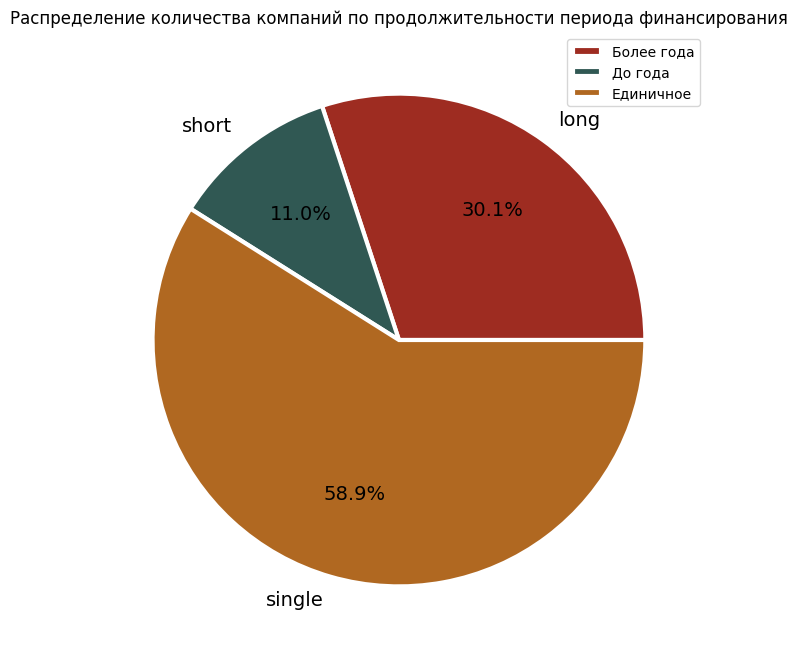

In [45]:
# Построим гистограмму
plt.figure(figsize = (8, 8))
df_per.plot(kind = 'pie', 
            legend = True,
           wedgeprops = {'edgecolor':'w', 'linewidth':3},
           autopct='%1.1f%%',
           textprops={'fontsize': 14},
           pctdistance=0.65,
           colors = ['#9E2C21', '#305853', '#B06821'],
           )
 
plt.title('Распределение количества компаний по продолжительности периода финансирования')
plt.xlabel('')
plt.ylabel('')
plt.legend(['Более года','До года','Единичное'], loc = 1)
plt.show()

Затем построим диаграмму, показывающую процентное соотношение суммы инвестиций по каждой группе.

In [46]:
# Создадим датафрейм с суммой инвестиций для каждой группы
df_per_usd = invest.groupby('fin_period')['funding_total_usd'].sum()
df_per_usd

fin_period
long     402740507604.00
short     48885731057.00
single   199295542759.00
Name: funding_total_usd, dtype: float64

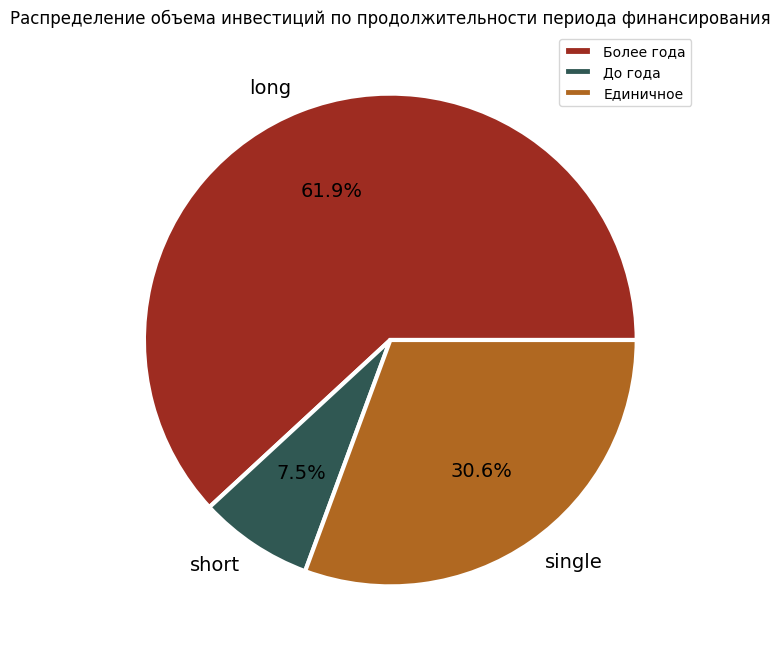

In [47]:
# Построим гистограмму
plt.figure(figsize = (8, 8))
df_per_usd.plot(kind = 'pie', 
            legend = True,
           wedgeprops = {'edgecolor':'w', 'linewidth':3},
           autopct='%1.1f%%',
           textprops={'fontsize': 14},
           pctdistance=0.65,
           colors = ['#9E2C21', '#305853', '#B06821']
           )
 
plt.title('Распределение объема инвестиций по продолжительности периода финансирования')
plt.xlabel('')
plt.ylabel('')
plt.legend(['Более года','До года','Единичное'], loc = 1)
plt.show()

Долгосрочное финансирование привлекло наибольший объем средств. Несмотря на то, что эта группа включает меньшее количество компаний, чем единичное, она аккумулировала 61,9% от общего объема инвестиций.
Единичное финансирование, хоть и является самой многочисленной группой по количеству компаний, привлекла ощутимо меньше средств — треть от общего объема.Краткосрочное финансирование получило наименьший объем инвестиций. Это отражает как меньшее число компаний в группе, так и меньшие объемы средств, привлеченные за короткий период.

Несмотря на то, что большая часть компаний ограничивается одним раундом финансирования, основные объемы инвестиций приходятся именно на долгосрочные проекты.

### 2.2 Выделение средних и нишевых сегментов рынка

Мы приступаем к анализу сегментов рынка, указанных компаниями в столбце market. Сначала рассчитаем частоту встречаемости каждого сегмента в датафрейме invest.

In [48]:
# Рассчитаем число компаний, входящих в каждый сегмент
srs_mark = invest['market'].value_counts()
srs_mark 

market
software                 4812
biotechnology            3590
unknown                  2500
mobile                   2343
e-commerce               1865
                         ... 
law enforcement             1
real estate investors       1
business productivity       1
musicians                   1
gold                        1
Name: count, Length: 395, dtype: int64

Далее категоризируем сегменты рынка на основе количества входящих в них компаний: сегменты с числом компаний более 120 мы отнесем к массовым, от 35 до 120 (включительно) — к средним, а до 35 компаний — к нишевым. Создадим отдельный столбец.

In [49]:
#Создадим столбец с категориями сегметов 
def fill_market(row):
    num = srs_mark[row]
    if num > 120:
        return 'mass'
    elif num <35:
        return 'niche'
    else:
        return 'mid'
       
invest['cat_market'] = invest['market'].apply(fill_market)

Рассчитаем сколько сегментов и сколько компаний попадает в каждую категорию

In [50]:
df_category = invest[invest['market'] != 'unknown'].groupby('cat_market').agg({'name': 'count', 'market':'nunique'})
df_category = df_category.reset_index()
df_category.columns = ['cat_market','count_comp', 'count_segm']
df_category

,cat_market,count_comp,count_segm
0,mass,33730,48
1,mid,3841,57
2,niche,830,289


Построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [51]:
# Подготовим датафрейм для построения графика
df_market = invest.groupby(['cat_market','market'])['name'].count()
df_market = df_market.reset_index()
df_market.columns = ['cat_market','market','count']
df_market = df_market[df_market['cat_market'].isin(['mid','niche'])]
df_market = df_market.sort_values(by = 'count', ascending = False)

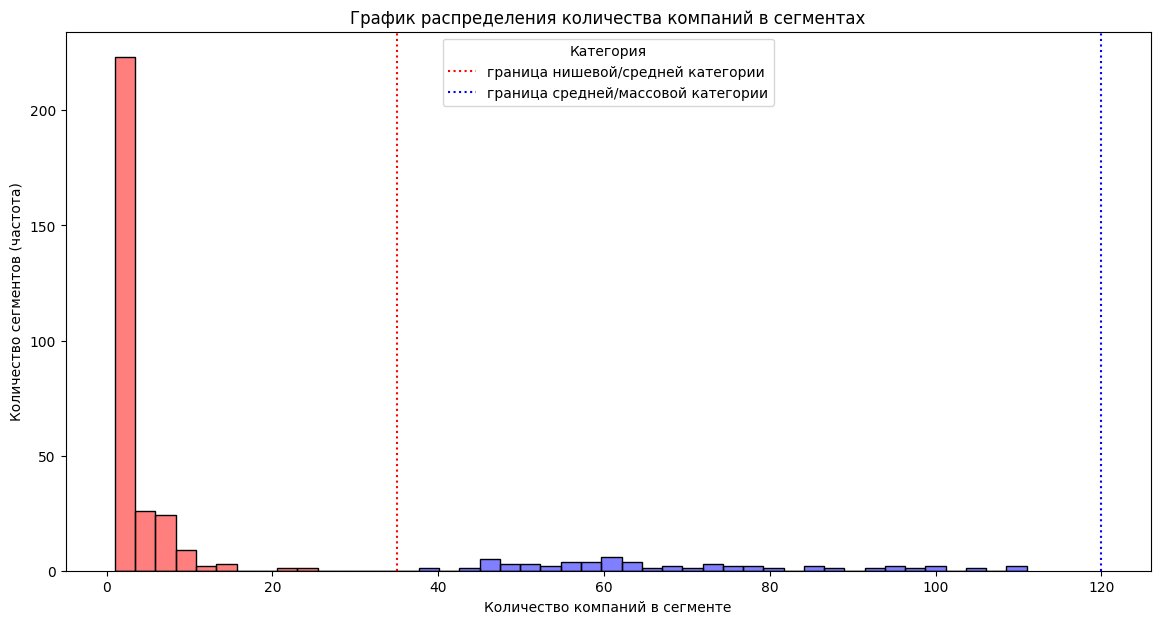

In [52]:
plt.figure(figsize = (14,7))

sns.histplot(data = df_market, x = 'count',
             bins = 45,
             hue = 'cat_market', 
             palette = ['blue','red'],
            legend = True)

plt.axvline(x = 35, color = 'red', linestyle = ':', label = 'граница нишевой/средней категории')
plt.axvline(x = 120, color = 'blue', linestyle = ':', label = 'граница средней/массовой категории')

plt.title('График распределения количества компаний в сегментах')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов (частота)')
plt.legend(title = 'Категория')
plt.show()

In [53]:
# Рассмотрим как распределяются компании и отрасли в массовом, среднем и нишевом сегменте
df_cat_plot = df_category.melt(id_vars ='cat_market')
df_cat_plot

,cat_market,variable,value
0,mass,count_comp,33730
1,mid,count_comp,3841
2,niche,count_comp,830
3,mass,count_segm,48
4,mid,count_segm,57
5,niche,count_segm,289


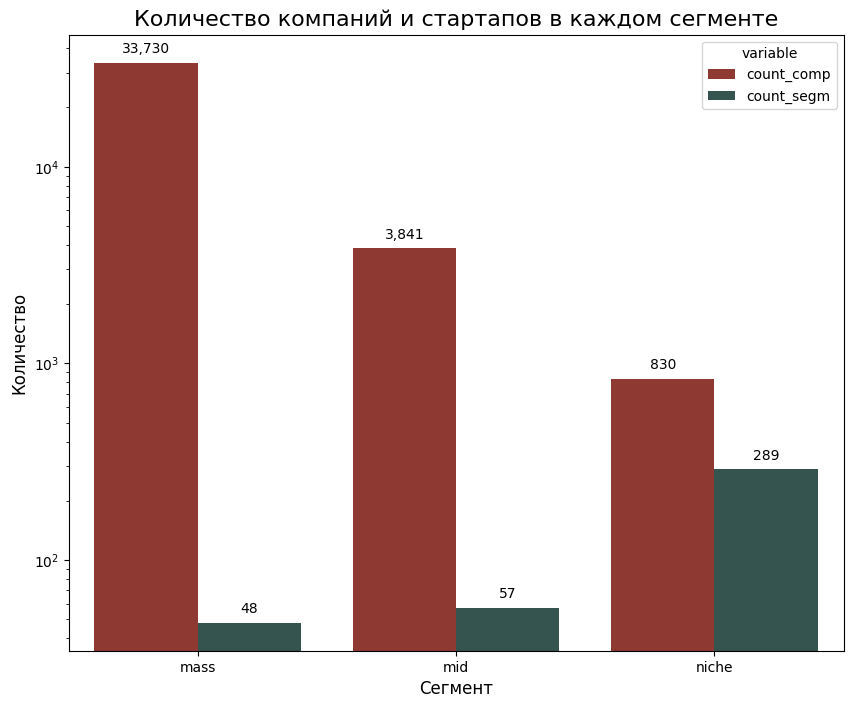

In [54]:
# Посторои график
plt.figure(figsize = (10, 8))
axis = sns.barplot(df_cat_plot, x = 'cat_market',  y = 'value', hue = 'variable', palette =['#9E2C21', '#305853'])

for p in axis.patches:
        height = p.get_height()
        # Используем ax.annotate вместо ax.text для точного контроля смещения
        axis.annotate(
            '{:,.0f}'.format(height),  # Текст метки
            (p.get_x() + p.get_width() / 2., height), # Точка привязки (центр верха столбца)
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            xytext=(0, 10),  # Смещение в ПИКСЕЛЯХ (10 пунктов вверх от точки привязки)
            textcoords='offset points' # Указываем, что xytext - это смещение в точках
        )

plt.yscale('log')
plt.xlabel('Сегмент', fontsize = 12)
plt.ylabel('Количество', fontsize = 12)
plt.title('Количество компаний и стартапов в каждом сегменте', fontsize = 16 )

plt.show()

Нишевая категорий лидирует по количеству сегментов рынка и является самой малочисленной по количеству компаний. Это говорит о том, что в нишевом сегменте располагаются более узкоспециализированные и специфичные отрасли. 

Массовый сегмент аккумулирует около 88% всех компаний. Подавляющее большинство игроков сосредоточено в небольшом числе популярных и крупных отраслей. Высокая плотность конкуренции в этих областях указывает как на их исключительную привлекательность для инвестиций, так и на насыщенность рынка.

In [55]:
top_mass = pd.DataFrame(invest[(invest['cat_market'] == 'mass') & (invest['market'] != 'unknown')].groupby('market')['name'].count().sort_values(ascending = False).head(10))
top_mass =  top_mass.reset_index()

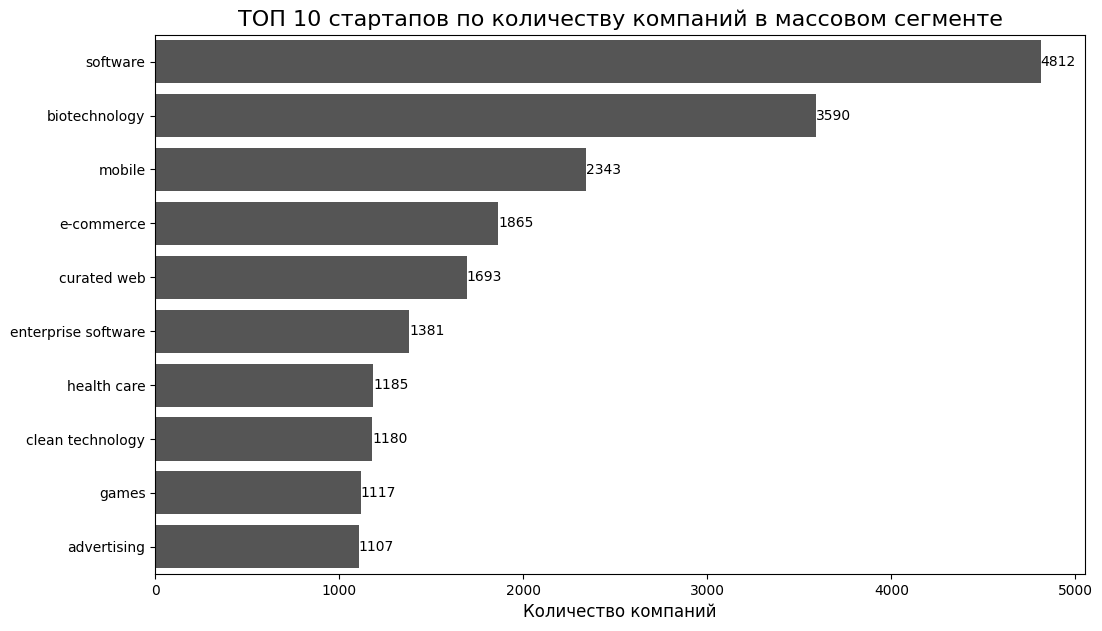

In [56]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(data = top_mass ,
            y = 'market',
            x = 'name',
            color = '#555555'
)

for p in ax.patches:
    # Получаем ширину столбца (фактическое значение данных)
    width = p.get_width()
    # Получаем координаты Y центра столбца
    y_center = p.get_y() + p.get_height() / 2.0
    
    # Добавляем текст (метку данных) справа от столбца
    ax.text(
        width -1,                 # Координата X (справа от конца столбца + небольшой отступ)
        y_center,                    # Координата Y (по центру столбца)
        f'{width:.0f}',             # Сам текст (форматируем как число с 1 знаком после запятой и знаком %)
        ha='left',                   # Выравнивание по горизонтали: слева от точки X
        va='center',                 # Выравнивание по вертикали: по центру точки Y
        color='black',               # Цвет текста
        fontsize=10                  # Размер шрифта
    )
    
# Настраиваем оформление графика
plt.title('ТОП 10 стартапов по количеству компаний в массовом сегменте', fontsize = 16)
plt.ylabel('')
plt.xlabel('Количество компаний', fontsize = 12)


# Выводим график
plt.show()

Лидером по популярности в массовом сегменте является программное обеспечение (Software), насчитывающее 4812 компаний.
Второе место занимает отрасль биотехнологий (Biotechnology) с показателем 3590.
Замыкают тройку лидеров мобильные технологии (Mobile), где зафиксировано 2343 участника рынка.

Рынок стартапов характеризуется концентрацией в массовых сегментах так как  большинство компаний  сосредоточено в нескольких крупных и популярных отраслях, что говорит об их высокой инвестиционной привлекательности и конкуренции.
Так же прослеживается фрагментация в нишем сегменте, что указывает на детализацию рынка и возможности для новых, уникальных проектов, хотя в каждой конкретной нише игроков немного.

В столбце `market` мы оставим оригинальные названия только для массовых сегментов. Значения для средних и нишевых сегментов
будут заменены на соответствующие заглушки: `mid` и `niche`.

In [57]:
#Заменим значения в столбце market на заглушки если они не относятся к массовым
def refill_market(row):
    if row['cat_market'] == 'mass':
        return row['market']
    else:
        return row['cat_market']
       
invest['market'] = invest.apply(refill_market, axis =1 )

Дальнейшие исследования будут проводиться с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматриваться не будут — они объединены в два общих сегмента.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Чтобы ответить на вопрос о типичном размере средств, предоставляемых компаниям в рассматриваемый период, мы для начала изучим статистические показатели столбца `funding_total_usd`.

In [58]:
# Изучим статистические показатели столбца funding_total_usd
invest['funding_total_usd'].describe(percentiles = [0.05, 0.25, 0.5, 0.75, 0.99])

count         40901.00
mean       15914568.87
std       168691084.90
min               1.00
5%            30000.00
25%          350000.00
50%         2000000.00
75%        10000000.00
99%       200000000.00
max     30079503000.00
Name: funding_total_usd, dtype: float64

Минимальная сумма финансирования в 1 доллар США, вероятно, является ошибкой в данных. Аналогично, максимальное значение инвестиций в 30 миллиардов долларов также может быть аномалией. Столь широкий диапазон значений свидетельствует о крайне неравномерном распределении сумм инвестиций. Среднее значение почти в восемь раз превышает медиану, что является характерным признаком скошенного распределения. Значительная разница между этими показателями указывает на то, что среднее "подтягивается" вверх из-за небольшого числа крайне крупных инвестиций, в то время как большинство компаний получают гораздо меньшие суммы.

Для оценки типичного размера финансирования компании мы построим диаграмму 'ящик с усами' (boxplot). Поскольку минимальное значение в 1 доллар и максимальное в 30 млрд долларов явно искажают общую картину (что подтверждается анализом 1-го и 99-го перцентилей), мы исключим эти экстремальные выбросы из столбца funding_total_usd перед визуализацией.

In [59]:
# Удаляем аномальные экстремумы
df_invest_usd = invest[(invest['funding_total_usd'] < invest['funding_total_usd'].max()) & 
    (invest['funding_total_usd'] > invest['funding_total_usd'].min())]

In [60]:
# Найдем межквартальный размах
iqr = invest['funding_total_usd'].quantile(0.75) - invest['funding_total_usd'].quantile(0.25)
# Вычислим нижний и верхний пороги для выбросов
low_out = invest['funding_total_usd'].quantile(0.25) - (1.5 * iqr)
up_out = invest['funding_total_usd'].quantile(0.75) + (1.5 * iqr)
print(f'''Межквартальный размах равен {iqr}, 
Нижний порог выброса равен {low_out},
Верхний порог выброса равен {up_out}''')

Межквартальный размах равен 9650000.0, 
Нижний порог выброса равен -14125000.0,
Верхний порог выброса равен 24475000.0


Так как нижний порог принял отрицательное значение, ограничим его нулем.

In [61]:
low_out = 0

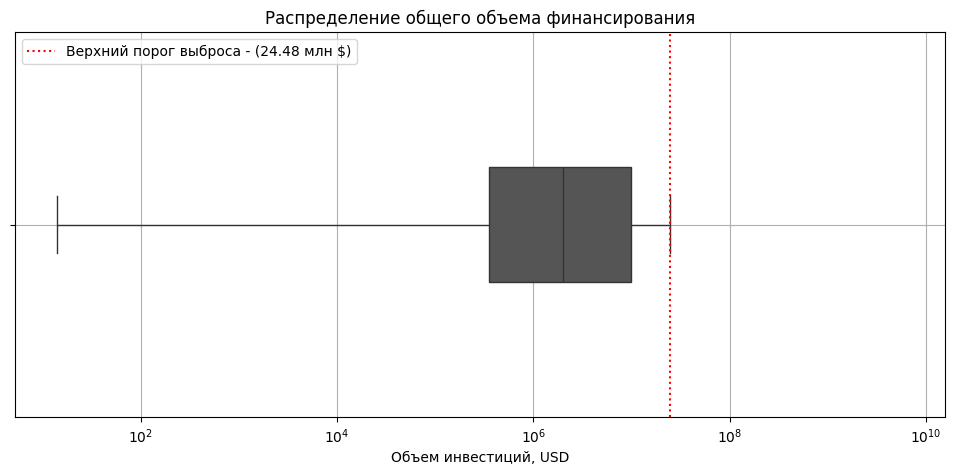

In [62]:
plt.figure(figsize=(12, 5))
sns.boxplot(data = df_invest_usd,
            x = 'funding_total_usd',
            width = 0.3, 
            fliersize = 0,
            color = '#555555'
            )
# Для нормального отображения воспользуемся логарифмической шкалой
plt.xscale('log')

plt.axvline(x = up_out, color = 'red', linestyle = ':', label = f'Верхний порог выброса - ({round(up_out/1000000,2)} млн $)')
plt.title('Распределение общего объема финансирования')
plt.xlabel('Объем инвестиций, USD')
plt.legend()
plt.grid()
plt.show()

Типичный интервал значений, в котором лежит большинство компаний, составляет от 0 до 24 475 000 USD.
Все значения, выходящие за этот диапазон, являются выбивающимися (аномальными).

Чтобы идентифицировать компании с аномалиями в финансировании, мы рассчитаем пороги методом **IQR** внутри каждого сегмента.

In [63]:
#Создадим датафрейм с верхним и нижним порогами выбросов для каждого сегмента
def calculate_outlier(group):
    iqr = group.quantile(0.75) - group.quantile(0.25)
    low_out = group.quantile(0.25) - (1.5 * iqr)
    if low_out < 0:
        low_out = 0
    up_out = group.quantile(0.75) + (1.5 * iqr)
    return pd.Series({'low_out':low_out,
                     'up_out' : up_out})
    
df_anomaly = invest.groupby('market')['funding_total_usd'].apply(calculate_outlier)
df_anomaly = df_anomaly.unstack(fill_value=0)

In [64]:
# Создадим колонку is_anomaly, c значениями True, если сумма финансирования компании выходит за границы выбросов по сегментам
def fill_anomaly(row):
    low_out = df_anomaly.loc[row['market'], 'low_out']
    up_out = df_anomaly.loc[row['market'], 'up_out']
    if row['funding_total_usd'] < low_out or row['funding_total_usd'] > up_out:
        return True
    else:
        return False
        
invest['is_anomaly'] = invest.apply(fill_anomaly, axis = 1)

In [65]:
# Создадим ТОП-15 сегментов по доле компаний с аномальными инвестициями
anomaly_market = invest.groupby('market')['is_anomaly'].mean()*100
anomaly_market = anomaly_market.sort_values(ascending = False)
anomaly_market = anomaly_market.head(15)
anomaly_market = anomaly_market.reset_index()

In [66]:
anomaly_market

,market,is_anomaly
0,real estate,17.20
1,entertainment,16.67
2,consulting,16.62
3,search,16.49
4,cloud computing,16.45
5,saas,16.18
6,photography,16.18
7,technology,15.97
8,video,15.96
9,niche,15.90


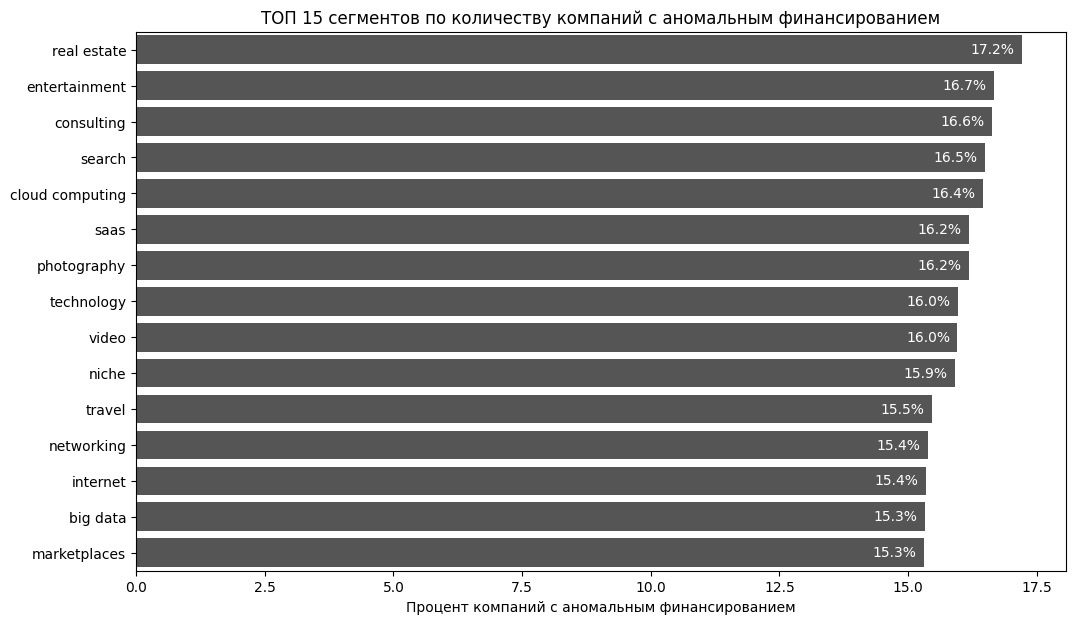

In [67]:
color_top = ['#555555']* 15
plt.figure(figsize=(12, 7))

ax = sns.barplot(data = anomaly_market,
            y = 'market',
            x = 'is_anomaly',
            hue = 'market',
            palette = color_top
)

for p in ax.patches:
    # Получаем ширину столбца (фактическое значение данных)
    width = p.get_width()
    # Получаем координаты Y центра столбца
    y_center = p.get_y() + p.get_height() / 2.0
    
    # Добавляем текст (метку данных) справа от столбца
    ax.text(
        width -1,                 # Координата X (справа от конца столбца + небольшой отступ)
        y_center,                    # Координата Y (по центру столбца)
        f'{width:.1f}%',             # Сам текст (форматируем как число с 1 знаком после запятой и знаком %)
        ha='left',                   # Выравнивание по горизонтали: слева от точки X
        va='center',                 # Выравнивание по вертикали: по центру точки Y
        color='w',               # Цвет текста
        fontsize=10                  # Размер шрифта
    )
    
# Настраиваем оформление графика
plt.title('ТОП 15 сегментов по количеству компаний с аномальным финансированием')
plt.ylabel('')
plt.xlabel('Процент компаний с аномальным финансированием')


# Выводим график
plt.show()

Исследование показало, что аномально высокие объемы финансирования чаще всего наблюдаются среди компаний, работающих в массовых сегментах рынка. Наивысшие показатели по доле аномалий демонстрируют сегменты недвижимости (17,20%), развлечений (16,67%) и консалтинга (16,62%). Большинство организаций из топ-15 представляют крупные массовые рынки, что вполне объяснимо, так как именно в этих областях сосредоточены крупнейшие инвестиционные сделки. Интересно отметить, что объединенная группа нишевых сегментов также занимает 10-е место в этом рейтинге (15,90%). Это указывает на то, что даже в рамках небольших, узкоспециализированных рынков можно встретить компании, которые привлекают значительно выделяющиеся суммы инвестиций.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Мы проверим полноту данных в датафрейме `invest` за 2014 год. Для этого мы сфокусируемся на столбце `first_funding_at`, 
который отражает дату первого финансирования и построим гистограмму, чтобы проанализировать распределение финансирования по дням в течение этого года. Рассматривать столбец с датой последнего финансирования не имеет смысла, поскольку данные в исходном датафрейме заканчиваются 31 декабря 2014 г.

In [68]:
# Создадим датафрейм, который отражает инвестиции по компаниям за 2014 г.
invest_2014 = invest[invest.loc[:,'first_funding_at'].dt.year == 2014]

In [69]:
invest_2014.shape

(6475, 43)

Получился датафрейм, содержащий 6475 строк. Теперь мы проанализируем распределение дат в нем, чтобы понять, какие конкретно временные интервалы 2014 года были охвачены финансированием компаний.

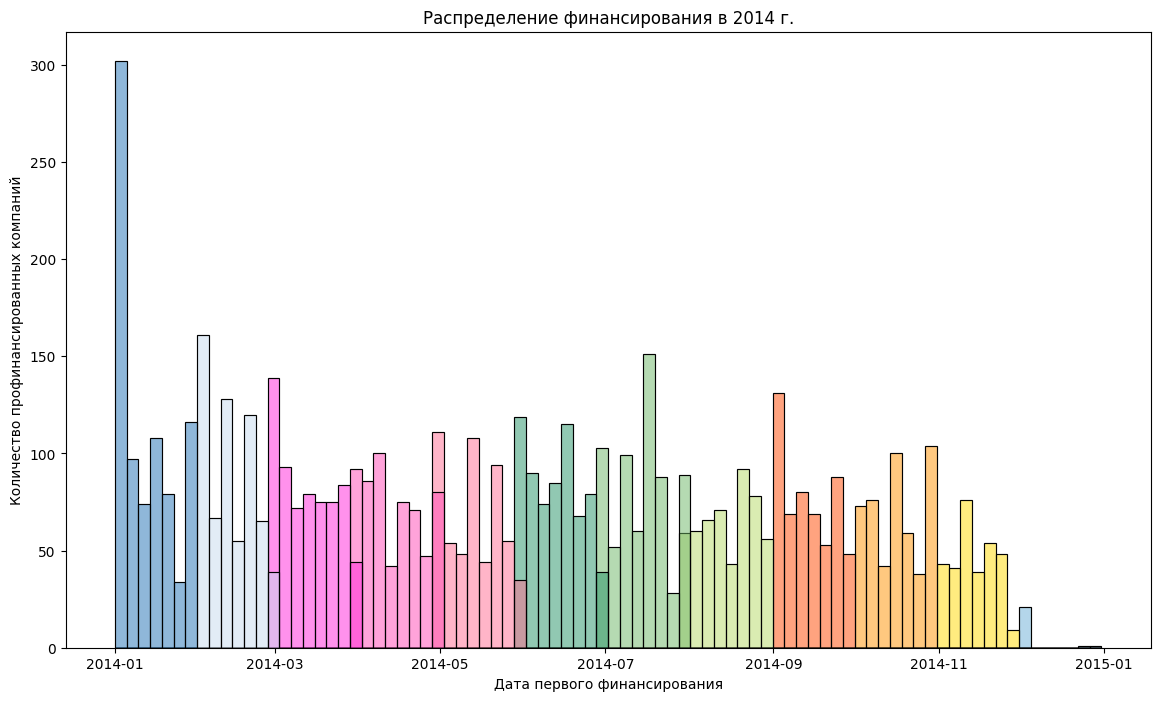

In [70]:
color_month = ['#2070b4', '#c6dbef', '#ff24db', '#ff49b6', '#ff6d92', '#249266', '#6db666', '#b6db66', '#ff4900', '#ff9200', '#ffdb00', '#6aaed6']
plt.figure(figsize = (14,8))

sns.histplot(data = invest_2014,
             x = 'first_funding_at',
            bins = 84,
            hue = invest_2014['first_funding_at'].dt.month,
            palette = color_month,
            legend = False)
plt.title('Распределение финансирования в 2014 г.')
plt.xlabel('Дата первого финансирования')
plt.ylabel('Количество профинансированных компаний')
plt.show()

На гистограмме распределения мы видим пропуски в данных в декабре 2014 года. Определим список дат в декабре, по которым отсутствуют данные.

In [71]:
# Проверим какие даты в декабре отсутствуют
invt = invest_2014[invest_2014['first_funding_at'].dt.month == 12]
invt['first_funding_at'].value_counts()

first_funding_at
2014-12-01    12
2014-12-02     9
2014-12-24     1
2014-12-31     1
Name: count, dtype: int64

In [72]:
# Проанализируем количество дат финансирования за тот же период в 2013 году
invest_2013 = invest[invest.loc[:,'first_funding_at'].dt.year == 2013]
invt1 = invest_2013[invest_2013['first_funding_at'].dt.month == 12]
invt1['first_funding_at'].nunique()

31

В датафрейме есть записи о финансировании только для четырех дней декабря: 1, 2, 24 и 31 декабря 2014 года. Все остальные даты в интервале со 2 по 24 декабря, а также с 24 по 31 декабря, отсутствуют. Мы наблюдаем значительные пробелы в данных за декабрь. Существует два объяснения: либо данные собраны не полностью, либо транзакции не проводились. Сравнительный анализ с декабрем 2013 года (где финансирование было ежедневным) заставляет нас предположить, что данные за 2014 год неполные. Несмотря на эти пропуски, мы принимаем решение включить 2014 год в дальнейшее исследование, поскольку отсутствующие значения составляют малую долю от общегодового объема и не окажут критического влияния на итоговый анализ.

Для дальнейшего анализа исключим из датафрейма все компании, ранее идентифицированные как получившие аномальное финансирование

In [73]:
# Отфильтруем компании, финансирование которых не было аномальным
invest = invest[invest['is_anomaly'] == False]
invest.shape

(35659, 43)

Отфильтруем датафрейм, оставив в нем только те компании, которые получали финансирование в годы, когда общее число раундов финансирования составляло 50 или более. Фильтрация будет производиться на основе данных из столбцов `mid_funding_at` и `funding_rounds`.

In [74]:
# Составим список годов, в которых было зафиксировано не менее 50 раундов финансирования
invest_year_count_round = invest.groupby(invest['mid_funding_at'].dt.year)['funding_rounds'].sum()
invest_year_count_round = invest_year_count_round[invest_year_count_round >=50]
years_count_round = list(invest_year_count_round.index)
years_count_round

[2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014]

In [75]:
# Отфильтруем итоговый датафрейм
invest = invest[invest['mid_funding_at'].dt.year.isin(years_count_round)]
invest.shape

(35585, 43)

Получившийся датафрейм содержит 35 585 строк и 43 столбца

### 3.3. Анализ типов финансирования по объёму и популярности

Проанализируем общие объемы инвестиций, привлеченных различными типами финансирования.
Построим график, чтобы наглядно продемонстрировать, какие из следующих типов финансирования аккумулировали наибольшее количество денег в абсолютном выражении:
- `seed` (инвестиций на посевной стадии)
- `venture` (венчурные инвестиций)
- `equity_crowdfunding` (инвестиции долевого краудфандинг)
- `undisclosed` (инансирования нераскрытого типа)
- `convertible_note` (инвестиции через конвертируемые займы)
- `debt_financing` (долговое финансирование)
- `angel` (инвестиций бизнес-ангелов)
- `grant` (гранты)
- `private_equity` (прямые инвестиции)
- `post_ipo_equity` (финансирования после IPO)
- `post_ipo_debt` (долговоге финансирование после IPO)
- `secondary_market` (вторичный рынок)
- `product_crowdfunding` (продуктовый краудфандинг).

In [76]:
# Составим список столбцов, относящихся к различным типам финансирования
invest_columns = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 
                  'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 
                  'product_crowdfunding']
# Создадим вспомогательный датафрейм для построения графика
type_finance = invest[invest_columns].sum().sort_values(ascending = False)
type_finance = type_finance.reset_index()
type_finance.columns = ['funding_type','total_amount']
type_finance['percentage'] = type_finance['total_amount'] / type_finance['total_amount'].sum() * 100
type_finance

,funding_type,total_amount,percentage
0,venture,129121030476.00,80.00
1,seed,9432587044.00,5.84
2,debt_financing,8178152734.00,5.07
3,private_equity,4843108504.00,3.00
4,angel,2478923836.00,1.54
5,undisclosed,2100352252.00,1.30
6,grant,1978798688.00,1.23
7,post_ipo_equity,1946452068.00,1.21
8,convertible_note,566039436.00,0.35
9,post_ipo_debt,286718349.00,0.18


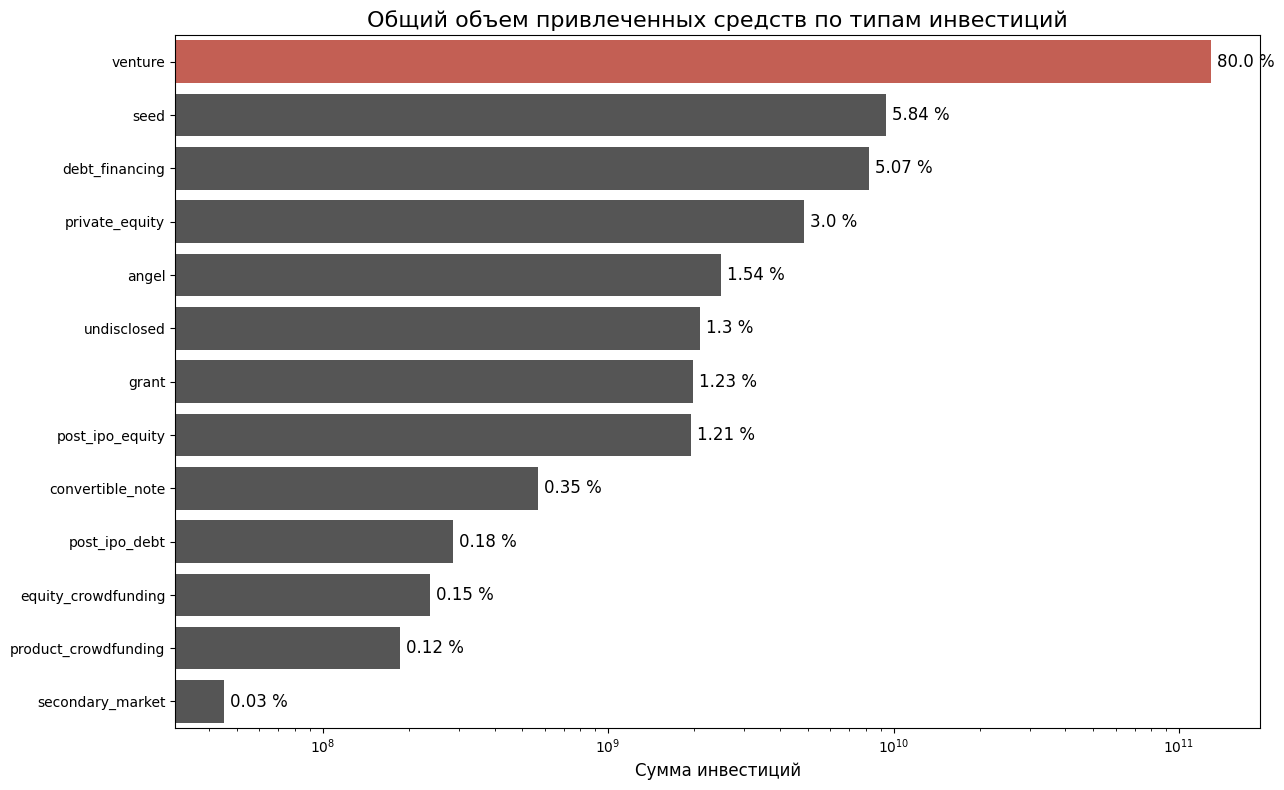

In [77]:
# Построим гистограмму

# Создадим цветовую палитру для графика
color_fin = ['#d55042']
color_fin.extend(['#555555'] * 12)

plt.figure(figsize = (14, 9))

ax = sns.barplot(data= type_finance,
            y = 'funding_type',
            x = 'total_amount', 
            hue = 'funding_type', 
            palette = color_fin)
for index, p in enumerate(ax.patches):
    # Получаем ширину столбца (фактическое значение данных)
    width = p.get_width()
    # Получаем координаты Y центра столбца
    y_center = p.get_y() + p.get_height() / 2.0
    percentage = round(type_finance['percentage'].iloc[index],2)
    text = f'{percentage} %'
    # Добавляем текст (метку данных) справа от столбца
    ax.text(
        width*1.05 ,                 # Координата X (справа от конца столбца + небольшой отступ)
        y_center,                    # Координата Y (по центру столбца)
        text,             # Сам текст (форматируем как число с 1 знаком после запятой и знаком %)
        ha='left',                   # Выравнивание по горизонтали: слева от точки X
        va='center',                 # Выравнивание по вертикали: по центру точки Y
        color='black',               # Цвет текста
        fontsize=12                  # Размер шрифта
    )
plt.xscale('log')
plt.title('Общий объем привлеченных средств по типам инвестиций', fontsize = 16)
plt.xlabel('Cумма инвестиций', fontsize = 12)
plt.ylabel('')
plt.show()

Основной объем привлеченных средств — 129,12 млрд. долларов (80%) — был обеспечен за счет венчурного финансирования. Инвестиции на посевной стадии и долговое финансирование заняли куда меньшую долю рынка: 9,4 млрд. долларов (5,84%) и 8,2 млрд. долларов. (5,07%) соответственно.

Изучим частоту использования типов финансирования: мы определим наиболее распространенные типы в наборе данных и визуализируем полученные результаты с помощью диаграммы.

In [78]:
# Создадим вспомогательный датафрейм, в котором будут агрегированы данные о количестве каждого типа инвестиций.
type_finance_count = (invest[invest_columns] > 0).sum().sort_values(ascending = False)
type_finance_count = type_finance_count.reset_index()
type_finance_count.columns = ['funding_type','total_count']
type_finance_count['percentage'] = type_finance_count['total_count'] / type_finance_count['total_count'].sum() * 100

type_finance_count

,funding_type,total_count,percentage
0,venture,18820,44.51
1,seed,13373,31.63
2,debt_financing,3265,7.72
3,angel,2935,6.94
4,grant,1002,2.37
5,undisclosed,813,1.92
6,private_equity,634,1.50
7,convertible_note,521,1.23
8,equity_crowdfunding,515,1.22
9,product_crowdfunding,204,0.48


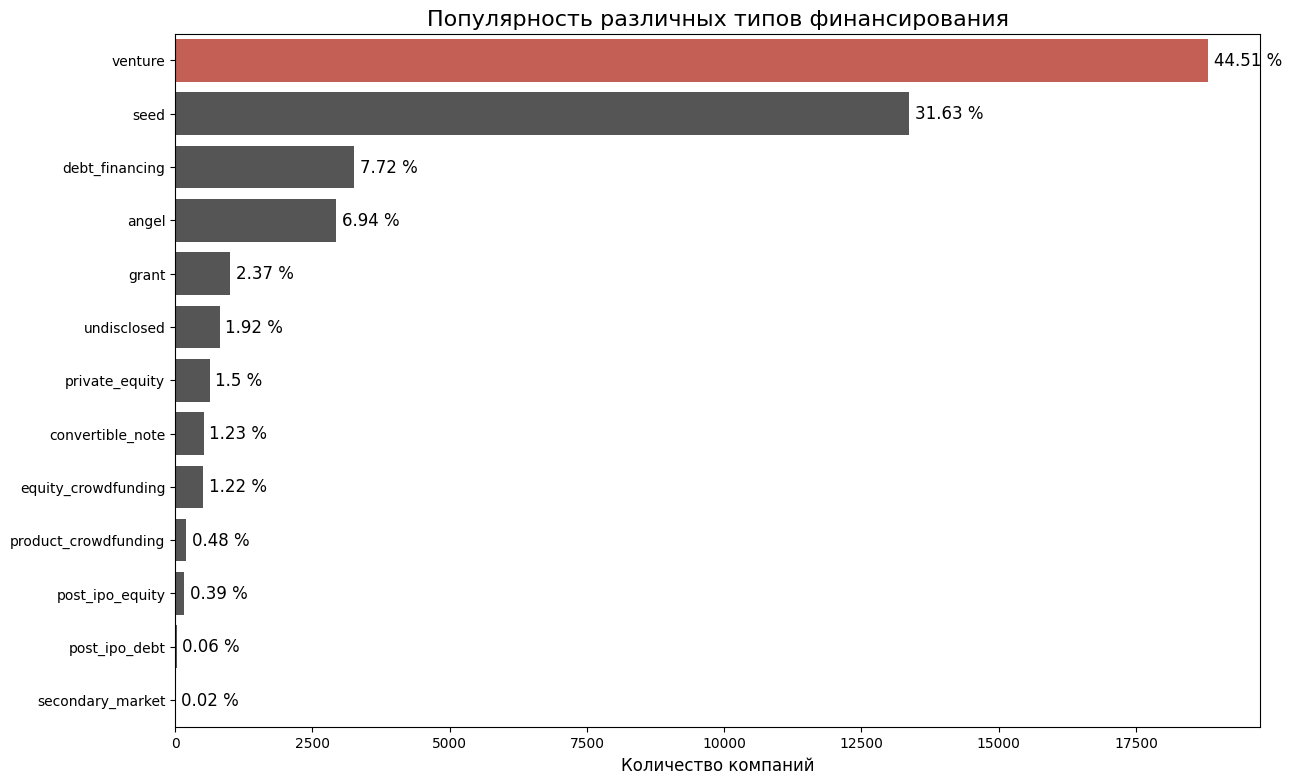

In [79]:
# Построим гистограмму

# Создадим цветовую палитру для графика
color_fin = ['#d55042']
color_fin.extend(['#555555'] * 12)

plt.figure(figsize = (14, 9))

ax = sns.barplot(data= type_finance_count,
            y = 'funding_type',
            x = 'total_count', 
            hue = 'funding_type', 
            palette = color_fin)
for index, p in enumerate(ax.patches):
    # Получаем ширину столбца (фактическое значение данных)
    width = p.get_width()
    # Получаем координаты Y центра столбца
    y_center = p.get_y() + p.get_height() / 2.0
    percentage = round(type_finance_count['percentage'].iloc[index],2)
    text = f'{percentage} %'
    # Добавляем текст (метку данных) справа от столбца
    ax.text(
        width + 100 ,                 # Координата X (справа от конца столбца + небольшой отступ)
        y_center,                    # Координата Y (по центру столбца)
        text,             # Сам текст (форматируем как число с 1 знаком после запятой и знаком %)
        ha='left',                   # Выравнивание по горизонтали: слева от точки X
        va='center',                 # Выравнивание по вертикали: по центру точки Y
        color='black',               # Цвет текста
        fontsize=12                  # Размер шрифта
    )
#plt.xscale('log')
plt.title('Популярность различных типов финансирования', fontsize = 16)
plt.xlabel('Количество компаний', fontsize = 12)
plt.ylabel('')
plt.show()

**Венчурное финансирование** является абсолютным лидером по обоим ключевым показателям: оно не только наиболее распространено (44,51% случаев), но и аккумулирует подавляющую часть всего капитала (80,00%). Это делает его как самым популярным, так и самым крупным типом инвестиций на рынке.

Несмотря на высокую частоту использования (второе место, 31,63% от общего числа случаев), **посевное финансирование** характеризуется относительно небольшим вкладом в общий объем инвестиций (5,84%). Такое расхождение между популярностью и объемом указывает на низкий средний размер сделок.Таким образом инвестиции на посевной стадии широко распространенный, но мелкомасштабный источник капитала для компаний на старте.

Далее перейдем к анализу общей суммы возвратов инвестиций: рассмотрим данные из датафрейма `returns` и визуализируем их с помощью графика.

In [80]:
# Создадим вспомогательный датафрейм
return_finance = returns.sum().sort_values(ascending = False)
return_finance = return_finance.reset_index()
return_finance.columns = ['funding_type','total_amount_returns']
return_finance['total_amount_returns']= return_finance['total_amount_returns']*1000000
return_finance['percentage'] = return_finance['total_amount_returns'] / return_finance['total_amount_returns'].sum() * 100
return_finance

,funding_type,total_amount_returns,percentage
0,venture,40578620000.00,74.10
1,debt_financing,4734850000.00,8.65
2,private_equity,3587330000.00,6.55
3,seed,2382240000.00,4.35
4,angel,1509230000.00,2.76
5,post_ipo_equity,1104960000.00,2.02
6,undisclosed,730880000.00,1.33
7,post_ipo_debt,91030000.00,0.17
8,convertible_note,34790000.00,0.06
9,secondary_market,5200000.00,0.01


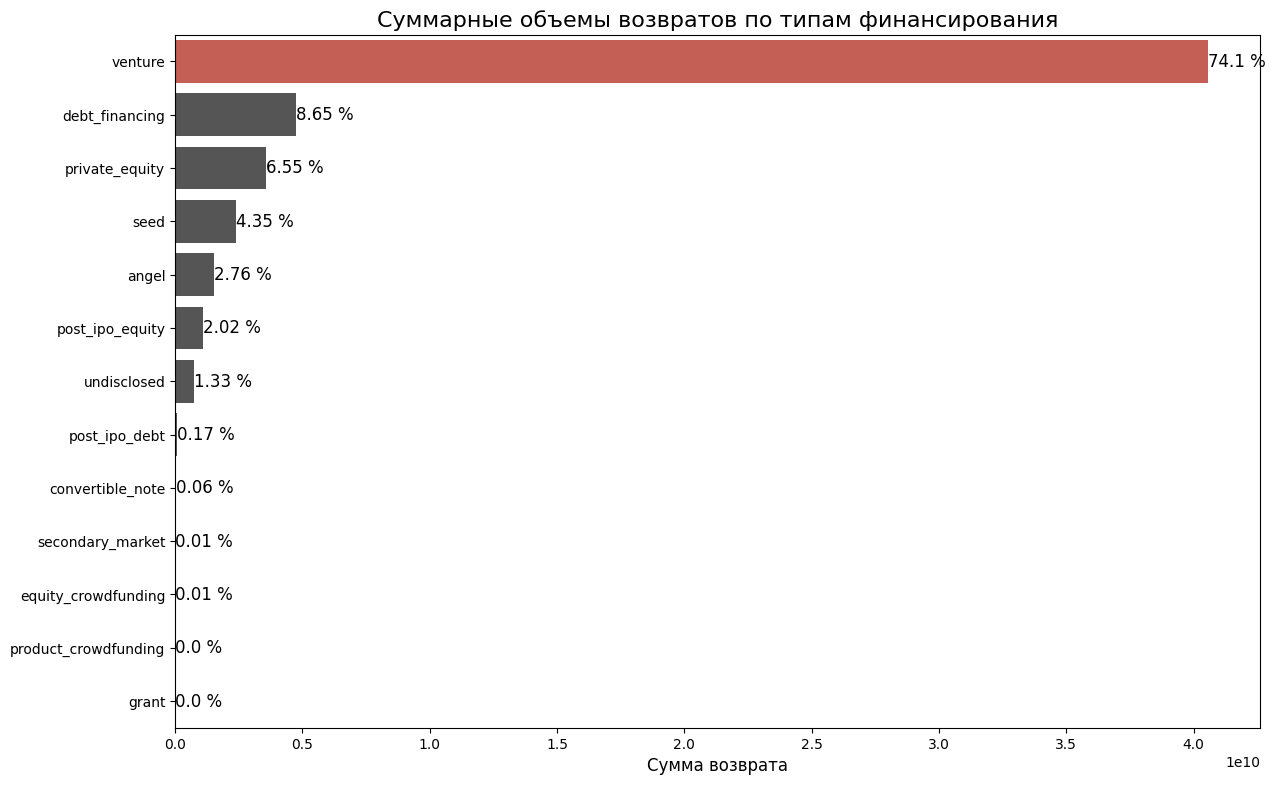

In [81]:
# Построим гистограмму

# Создадим цветовую палитру для графика
color_fin = ['#d55042']
color_fin.extend(['#555555'] * 12)

plt.figure(figsize = (14, 9))

ax = sns.barplot(data= return_finance,
            y = 'funding_type',
            x = 'total_amount_returns', 
            hue = 'funding_type', 
            palette = color_fin)
for index, p in enumerate(ax.patches):
    # Получаем ширину столбца (фактическое значение данных)
    width = p.get_width()
    # Получаем координаты Y центра столбца
    y_center = p.get_y() + p.get_height() / 2.0
    percentage = round(return_finance['percentage'].iloc[index],2)
    text = f'{percentage} %'
    # Добавляем текст (метку данных) справа от столбца
    ax.text(
        width + 100 ,                 # Координата X (справа от конца столбца + небольшой отступ)
        y_center,                    # Координата Y (по центру столбца)
        text,             # Сам текст (форматируем как число с 1 знаком после запятой и знаком %)
        ha='left',                   # Выравнивание по горизонтали: слева от точки X
        va='center',                 # Выравнивание по вертикали: по центру точки Y
        color='black',               # Цвет текста
        fontsize=12                  # Размер шрифта
    )
#plt.xscale('log')
plt.title('Суммарные объемы возвратов по типам финансирования', fontsize = 16)
plt.xlabel('Сумма возврата', fontsize = 12)
plt.ylabel('')
plt.show()

Большая часть возвратов инвестиций — 40,58 млрд. или 74,10% от общей суммы — была получена за счет **венчурного финансирования**. Это резко контрастирует с объемами возвратов от других источников: долговое финансирование (4,73 млрд, 8,65%) и прямые инвестиции (3,59 млрд, 6,55%) принесли на порядок меньше. Гранты, по понятным причинам, не показали возвратов (0,00). Эти результаты убедительно демонстрируют, что венчурные инвестиции являются наиболее прибыльным типом финансирования.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Рассчитаем для каждой компании средний объём одного раунда финансирования, используя столбцы `funding_total_usd` и `funding_rounds`. Создадим отдельный столбец в датафрейме

In [82]:
# Создадим столбец avg_vol
invest['avg_vol'] = invest['funding_total_usd']/invest['funding_rounds']

Теперь проанализируем, как менялся по годам типичный объем финансирования, привлекаемого стартапами в рамках одного инвестиционного раунда.

In [83]:
# Создадим вспомогательный датафрейм
typical_avg_vol = invest.groupby(invest['mid_funding_at'].dt.year)['avg_vol'].median().sort_values(ascending = False)
typical_avg_vol = typical_avg_vol.reset_index()
typical_avg_vol.columns = ['year', 'avg_vol']
typical_avg_vol

,year,avg_vol
0,2005,4500000.00
1,2006,3900000.00
2,2002,3225000.00
3,2004,3000000.00
4,2007,2879166.67
5,2000,2250000.00
6,2008,2170743.75
7,2001,1570886.00
8,2003,1500000.00
9,2009,1498475.00


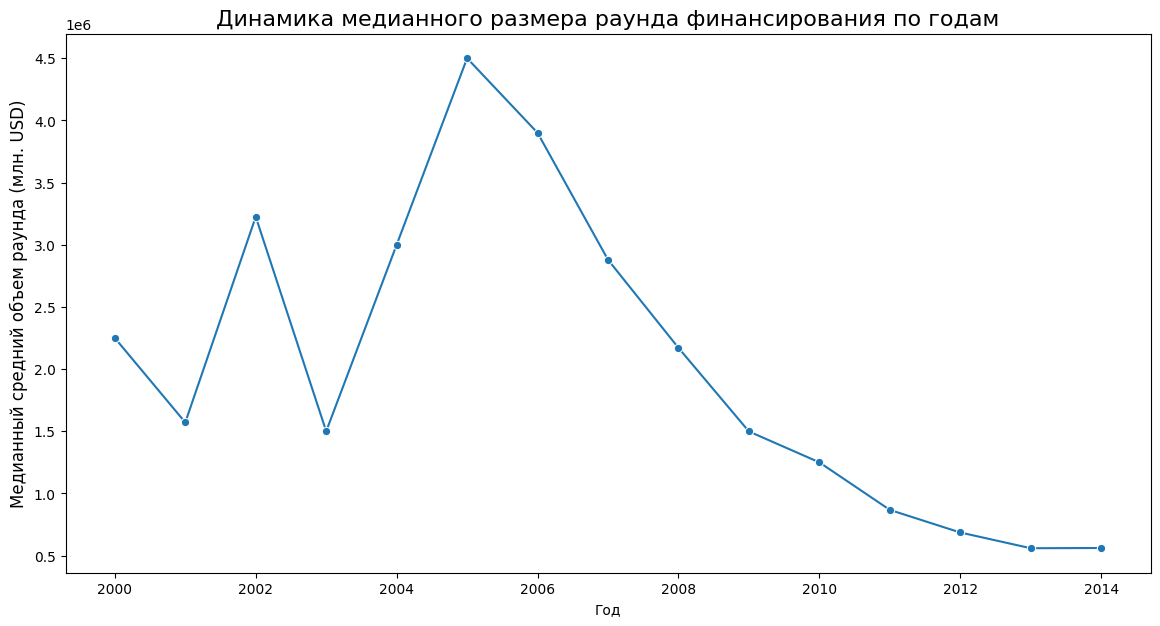

In [84]:
# Построим график
plt.figure(figsize = (14, 7))

sns.lineplot(data =typical_avg_vol, x = 'year', y = 'avg_vol', marker = 'o')

plt.title('Динамика медианного размера раунда финансирования по годам', fontsize = 16)
plt.xlabel('Год')
plt.ylabel('Медианный средний объем раунда (млн. USD)', fontsize = 12)
plt.show()

Следующий шаг — изучение динамики общего числа раундов финансирования по годам, чтобы понять степень интенсивности инвестиционной деятельности на рынке.

In [85]:
# Создадим вспомогательный датафрейм
typical_count = invest.groupby(invest['mid_funding_at'].dt.year)['funding_rounds'].sum().sort_values(ascending = False)
typical_count  = typical_count.reset_index()
typical_count.columns = ['year', 'count']
typical_count

,year,count
0,2013,12879
1,2012,9707
2,2011,7578
3,2014,7122
4,2010,6134
5,2009,4617
6,2008,3663
7,2007,2842
8,2006,1849
9,2005,948


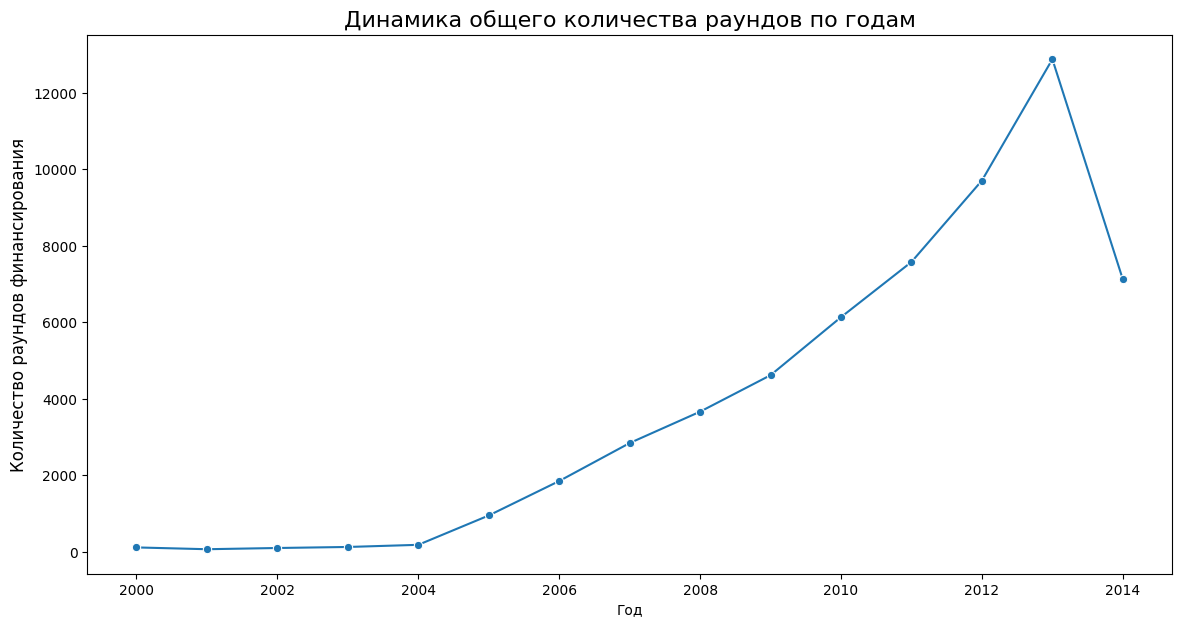

In [86]:
# Построим график
plt.figure(figsize = (14, 7))

sns.lineplot(data =typical_count, x = 'year', y = 'count', marker= 'o')

plt.title('Динамика общего количества раундов по годам', fontsize = 16)
plt.xlabel('Год')
plt.ylabel('Количество раундов финансирования', fontsize = 12)
plt.show()

Рынок инвестиций в период с 2000 по 2014 годы демонстрировал две разнонаправленные тенденции. Максимальный средний объем финансирования за раунд был достигнут в 2005 году (4,5 млн USD), после чего наблюдалось его устойчивое снижение, достигшее минимума в 2013–2014 годах.
Одновременно с этим, количество раундов непрерывно росло с 2004 года, достигнув своего пика в 2013 году. В 2014 году активность немного снизилась, но осталась на высоком уровне.
В итоге, 2014 год характеризовался высокой частотой инвестиционных сделок при относительно небольшом среднем размере каждого отдельного раунда.

Вероятно, эти тенденции связаны с тем, что инвесторы изменили свою стратегию и стали осторожнее. Они начали «дробить» крупные суммы, вкладывая деньги сразу в несколько стартапов из разных отраслей. Это помогает им снизить риски и увеличить шансы, что хотя бы один проект принесет большую прибыль.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, отображающую суммарный объем финансирования по сегментам рынка и годам. Цель — выделить из нее только те сегменты, чей объем финансирования увеличился в 2014 году по сравнению с предыдущим, 2013 годом.

In [87]:
# Создадим сводную таблицу
pt = invest.pivot_table(index = 'market', columns = invest['mid_funding_at'].dt.year, values = 'funding_total_usd', aggfunc = 'sum', fill_value = 0)
pt['funding_delta'] = pt[2014] - pt[2013]
pt = pt[pt['funding_delta'] > 0]

In [88]:
# Отберем только массовые сегменты исключив средние и нищевые.
pt = pt[(pt.index != 'mid') & (pt.index != 'niche')]
# Отфильтруем только те года, за которые есть достаточно данных
mask = (pt != 0).all(axis = 0)
pt = pt.loc[:, mask]
pt = pt.drop('funding_delta', axis = 1)
# Удалим сегмент unknown из полученной таблицы, поскольку это значение использовалось для обозначения пропущенных данных (NaN)
pt = pt.drop('unknown', axis = 0)
pt = pt.T

In [89]:
pd.options.display.float_format = '{:_.2f}'.format

In [90]:
pt

market,apps,big data,design,internet,manufacturing,medical,real estate,saas,startups,technology
mid_funding_at,,,,,,,,,,
2008,4_300_000.00,2_452_515.00,5_944_302.00,23_412_964.00,173_054_260.00,28_812_744.00,46_613_100.00,27_226_900.00,5_010_387.00,277_726_238.00
2009,7_219_000.00,597_375.00,2_150_144.00,38_195_773.00,422_862_531.00,11_566_200.00,38_840_213.00,13_536_585.00,460_700.00,36_078_850.00
2010,6_123_779.00,39_233_297.00,17_239_975.00,36_657_500.00,244_329_661.00,25_590_338.00,37_344_608.00,32_609_390.00,2_111_966.00,312_526_805.00
2011,18_374_071.00,60_369_158.00,8_899_967.00,36_859_032.00,561_639_285.00,28_540_962.00,20_015_128.00,32_223_749.00,19_654_403.00,143_222_700.00
2012,32_601_125.00,86_413_341.00,39_630_692.00,28_288_685.00,522_205_168.00,44_039_600.00,77_320_857.00,49_699_912.00,12_358_782.00,193_334_875.00
2013,28_868_621.00,78_698_922.00,60_958_835.00,69_732_096.00,393_936_634.00,64_469_424.00,92_207_655.00,79_576_613.00,18_080_552.00,120_873_887.00
2014,66_237_730.00,79_232_600.00,68_988_516.00,117_830_756.00,416_332_314.00,175_236_064.00,115_567_364.00,92_807_752.00,41_501_837.00,202_018_937.00


Отразим каждый сегмент на отдельных графиках, которые отобразят как менялся суммарный размер общего финансирования с 2008 по 2014 гг.

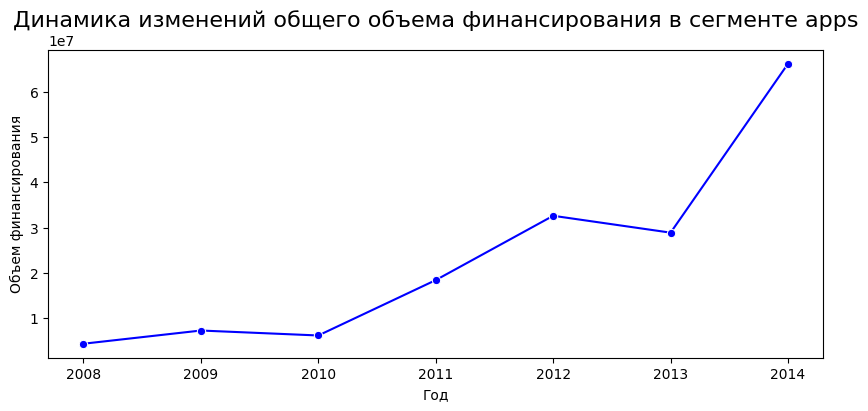

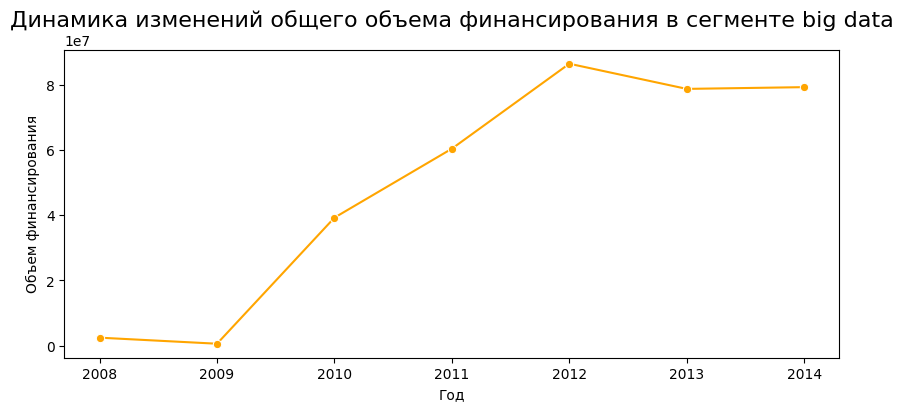

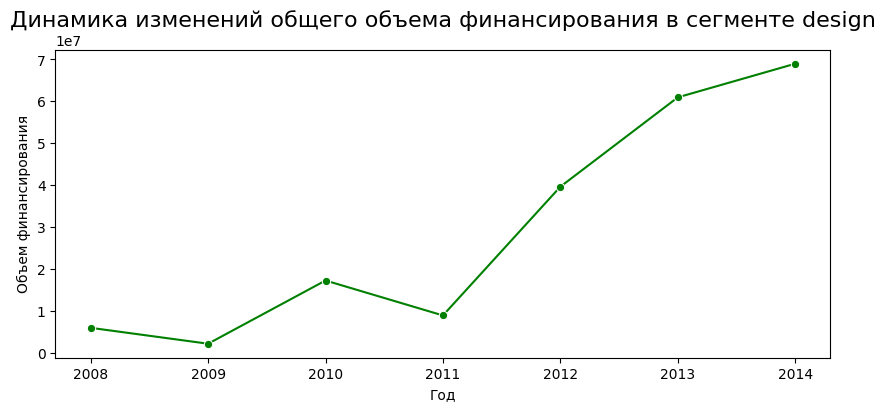

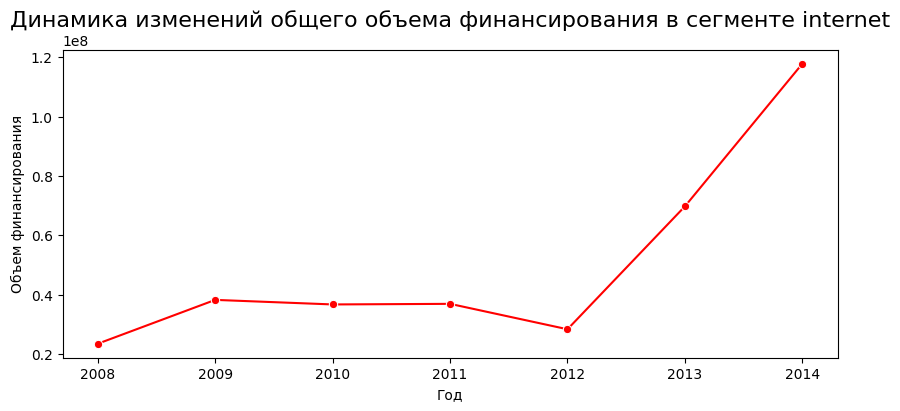

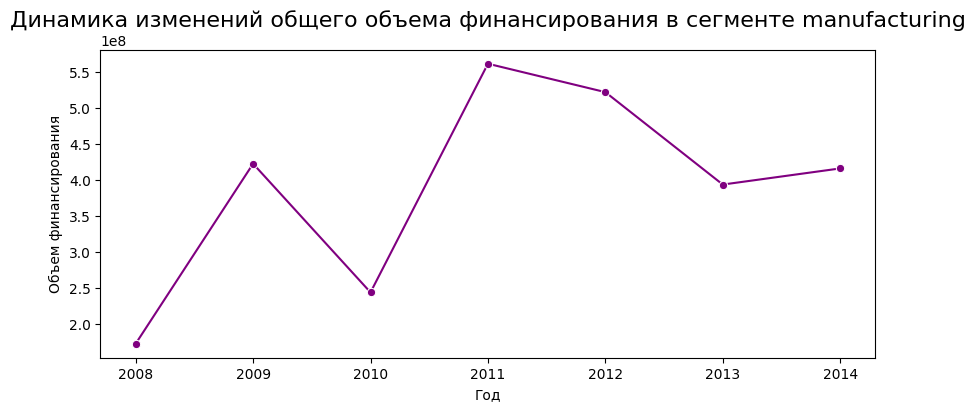

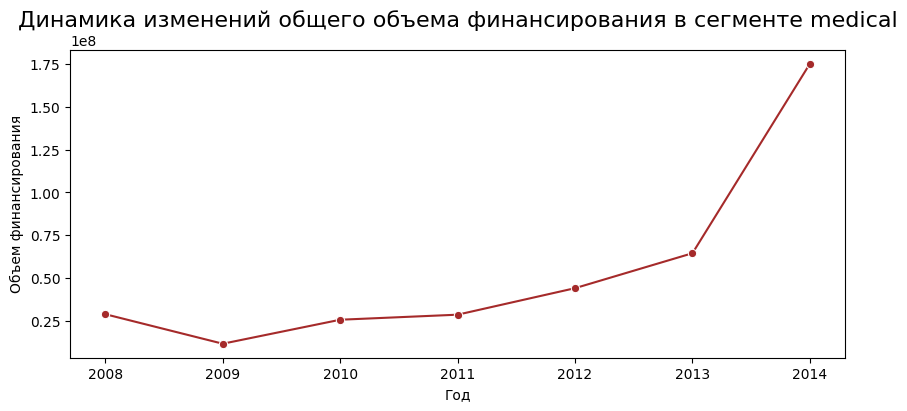

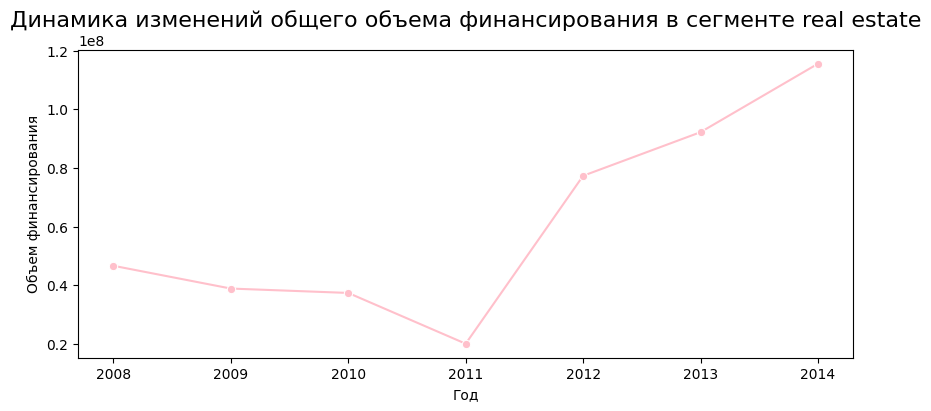

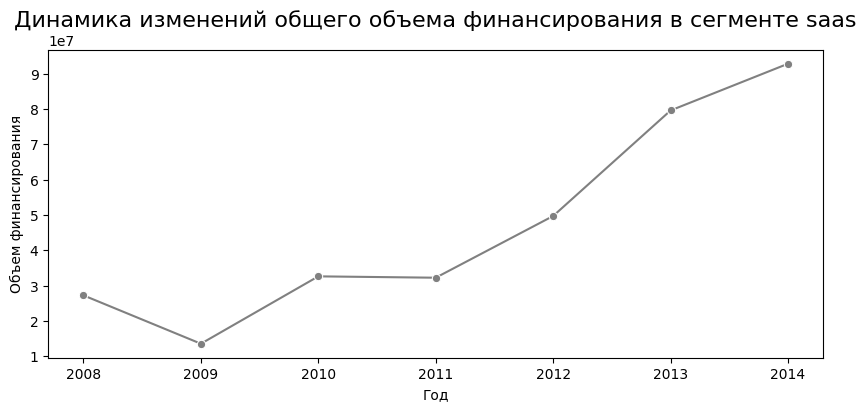

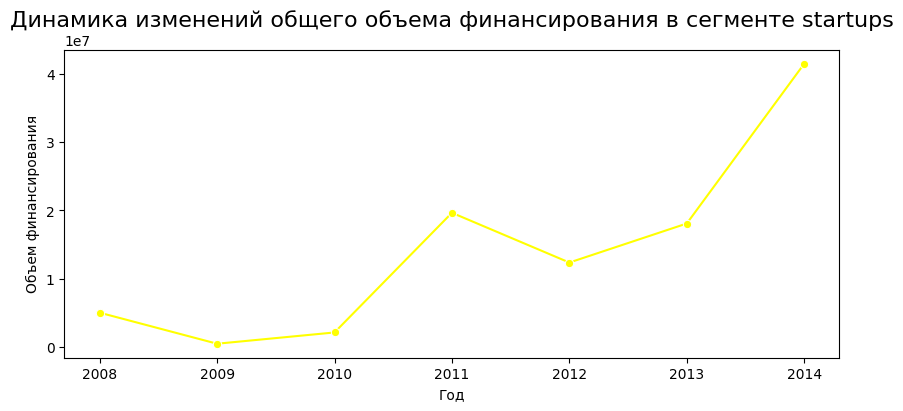

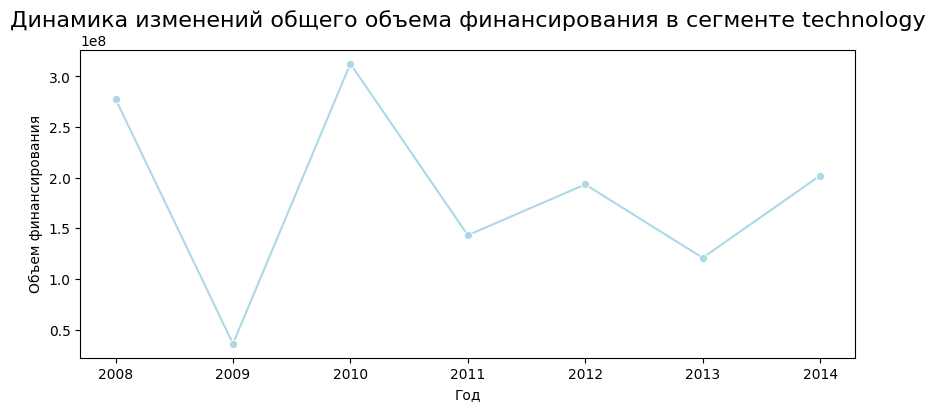

In [91]:
color_dict = {0: 'blue',
             1: 'orange',
             2: 'green',
             3: 'red',
             4: 'purple',
             5: 'brown',
             6: 'pink',
             7: 'grey',
             8: 'yellow', 
             9: 'lightblue'}
for index, column in enumerate(pt.columns):
    plt.figure(figsize = (10, 4))
    sns.lineplot(data = pt[column], marker= 'o', color = color_dict[index])

    plt.title(f'Динамика изменений общего объема финансирования в сегменте {column}', fontsize = 16)
    plt.xlabel('Год')
    plt.ylabel ('Объем финансирования')
    plt.show()

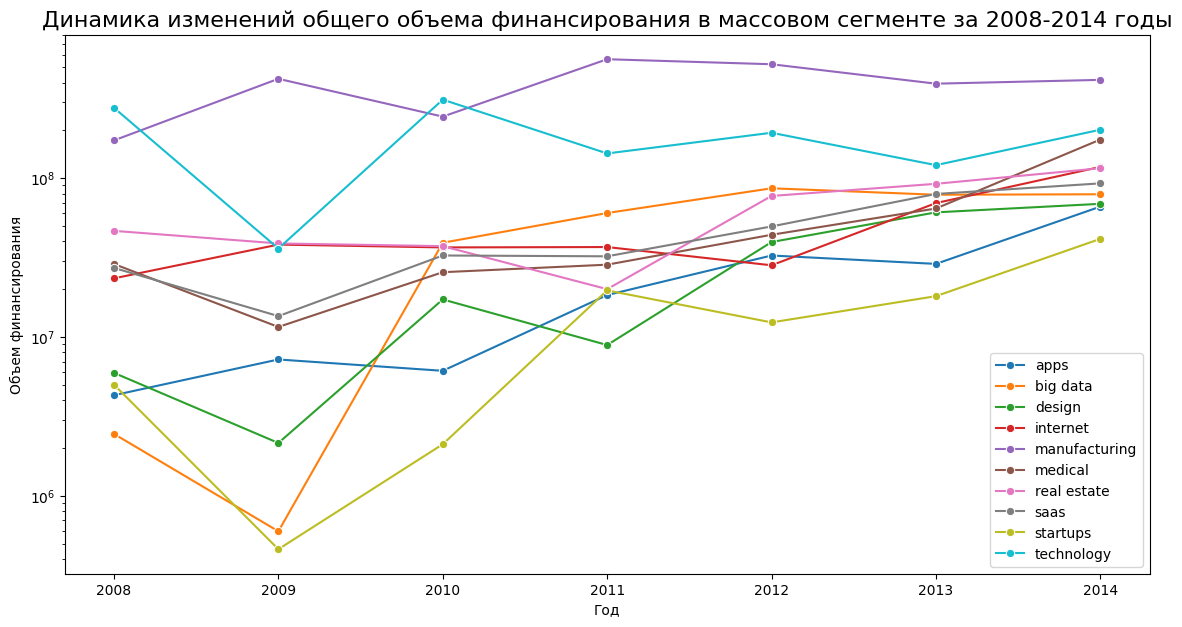

In [92]:
plt.figure(figsize = (14, 7))

for column in pt.columns:
    sns.lineplot(data = pt[column], marker= 'o', label = column)

plt.yscale('log')

plt.title('Динамика изменений общего объема финансирования в массовом сегменте за 2008-2014 годы', fontsize = 16)
plt.xlabel('Год')
plt.ylabel ('Объем финансирования')
plt.show()

**apps (Приложения)**: 
С 2010 по 2014 год этот сегмент демонстрирует впечатляющий, почти линейный и быстрый рост объема финансирования, с резким увеличением финансирования в 2014 году, что свидетельствует о активном развитии рынка мобильных и веб-приложений.

**big data**: 
Хотя этот сегмент показывает сильный рост в начале периода, его динамика замедляется и стабилизируется в 2013–2014 годах.

**design (Дизайн)**:
Сегмент демонстрирует устойчивую положительную динамику финансирования с заметным ускорением роста во второй половине рассматриваемого периода (20011–2014 гг.)

**internet (Интернет)**: 
Этот сегмент показывает  устойчивую и восходящую динамику финансирования в период с 2008 по 2014 год, с особенно выраженным ростом в последние два года.

**medical (Медицинские технологии)**: 
К концу рассматриваемого периода рост этого сегмента становится особенно заметным: в 2014 году объем финансирования увеличился более чем в два с половиной раза по сравнению с 2013 годом, что указывает на значительный рост инвестиционного интереса.

**real estate (Недвижимость)**: 
После первоначального снижения финансирования, достигшего минимума в 2011 году, сегмент продемонстрировал фазу быстрого и устойчивого роста.

**saas (software as a service) (Програмное обеспечение как услуга)**:
Сегмент демонстрирует очень уверенный, стабильный и поступательный рост c 2009 года. Это один из наиболее надежных и быстрорастущих сегментов.

**startups (Стартапы)**:
Сегмент показыл самые низкие объемы финансирования и значительную волатильность в период с 2008 по 2013 год. Тем не менее, в 2014 году произошел резкий рост инвестиций, который существенно повысил уровень активности в этом сегменте

**manufacturing (Производство)** и **technology (Технологии)** занимают ведущие позиции по общему объему инвестиций, но их темпы роста демонстрируют выраженную волатильность (колебания)

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Для каждого года и каждого вида финансирования рассчитаем нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, заменим на пропуски. Для этого сначала создадим вспомогательный датафрейм из датафрейма `invest`.

In [93]:
# Создадим вспомогательный датафрейм
invest_year_type = invest.groupby(invest['mid_funding_at'].dt.year)[invest_columns].sum()
invest_year_type 

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
mid_funding_at,,,,,,,,,,,,,
2000,16_759_140.00,327_962_152.00,0.00,112_202_640.00,0.00,14_000_000.00,24_086_333.00,293_114.00,0.00,3_467_747.00,0.00,7_718_867.00,0.00
2001,2_667_675.00,217_519_117.00,0.00,36_596_784.00,1_500_000.00,5_829_217.00,1_000_000.00,100_000.00,0.00,0.00,0.00,0.00,0.00
2002,10_465_192.00,306_940_622.00,0.00,42_323_731.00,0.00,15_309_671.00,3_000_000.00,0.00,7_500_000.00,300_000.00,0.00,0.00,0.00
2003,15_318_355.00,372_234_425.00,0.00,10_280_000.00,0.00,1_050_000.00,5_629_661.00,16_850_717.00,0.00,0.00,0.00,0.00,0.00
2004,18_104_728.00,664_150_451.00,0.00,62_912_359.00,0.00,30_816_623.00,11_013_741.00,10_363_600.00,0.00,0.00,0.00,0.00,0.00
2005,39_425_198.00,4_809_710_779.00,0.00,8_871_332.00,0.00,101_720_656.00,60_914_621.00,6_266_481.00,5_000_000.00,4_796_022.00,0.00,0.00,0.00
2006,66_794_774.00,9_020_604_123.00,933_057.00,61_545_498.00,10_702_385.00,140_848_395.00,70_756_153.00,6_147_500.00,17_820_244.00,0.00,0.00,0.00,0.00
2007,192_296_481.00,12_062_091_399.00,0.00,109_649_902.00,14_116_788.00,208_601_638.00,201_152_441.00,34_237_779.00,153_370_229.00,12_000_000.00,0.00,0.00,0.00
2008,302_003_020.00,14_234_730_391.00,0.00,119_920_337.00,28_600_902.00,428_622_061.00,249_299_613.00,23_485_347.00,191_756_331.00,36_000_000.00,0.00,0.00,1_000_000.00


Чтобы сравнить суммы возвратов (`returns`, в млн. USD) с объемами инвестиций (`invest_year_type`, в USD), мы стандартизируем данные и переведем все значения в `returns` в абсолютные доллары.

In [94]:
# Создадим датафрейм, в котором переведем значения в абсолютные доллары.
returns_corr = returns * 1_000_000
returns_corr

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16_700_000.00,55_400_000.00,0.00,78_210_000.00,0.00,8_660_000.00,6_430_000.00,0.00,0.00,940_000.00,0.00,200_000.00,0.00
2001,2_880_000.00,23_490_000.00,0.00,21_500_000.00,10_000.00,4_490_000.00,1_180_000.00,0.00,0.00,460_000.00,0.00,460_000.00,0.00
2002,6_590_000.00,209_420_000.00,0.00,25_770_000.00,20_000.00,3_420_000.00,3_410_000.00,0.00,1_510_000.00,340_000.00,0.00,60_000.00,0.00
2003,7_740_000.00,233_860_000.00,0.00,9_400_000.00,10_000.00,1_090_000.00,3_410_000.00,0.00,1_620_000.00,2_110_000.00,0.00,80_000.00,0.00
2004,9_930_000.00,555_900_000.00,0.00,33_190_000.00,10_000.00,13_550_000.00,9_180_000.00,0.00,2_190_000.00,3_380_000.00,0.00,550_000.00,0.00
2005,26_600_000.00,2_628_920_000.00,0.00,9_510_000.00,20_000.00,35_090_000.00,31_060_000.00,0.00,2_400_000.00,3_510_000.00,0.00,50_000.00,0.00
2006,61_810_000.00,3_100_180_000.00,190_000.00,46_740_000.00,1_780_000.00,113_210_000.00,47_750_000.00,0.00,16_670_000.00,20_580_000.00,0.00,120_000.00,0.00
2007,70_410_000.00,3_585_370_000.00,10_000.00,55_370_000.00,3_220_000.00,125_680_000.00,164_510_000.00,0.00,88_810_000.00,24_360_000.00,0.00,570_000.00,0.00
2008,89_720_000.00,2_717_020_000.00,30_000.00,41_020_000.00,1_710_000.00,397_540_000.00,102_830_000.00,0.00,130_380_000.00,84_280_000.00,0.00,470_000.00,0.00


Для расчета доли возвращенных средств, мы разделим общую сумму возвратов на суммарный объем привлеченного финансирования для каждого конкретного года, добавив к знаменателю минимальное число (1e-60) для предотвращения ошибки деления на ноль.

In [95]:
df = returns_corr/(invest_year_type + 1e-60)
df

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,1.00,0.17,0.00,0.70,0.00,0.62,0.27,0.00,0.00,0.27,0.00,0.03,0.00
2001,1.08,0.11,0.00,0.59,0.01,0.77,1.18,0.00,0.00,460_000_000_000_000_001_038_382_920_363_605_052...,0.00,460_000_000_000_000_001_038_382_920_363_605_052...,0.00
2002,0.63,0.68,0.00,0.61,20_000_000_000_000_000_426_408_380_189_087_937_...,0.22,1.14,0.00,0.20,1.13,0.00,60_000_000_000_000_004_202_228_415_229_069_648_...,0.00
2003,0.51,0.63,0.00,0.91,10_000_000_000_000_000_213_204_190_094_543_968_...,1.04,0.61,0.00,1_620_000_000_000_000_019_924_062_422_007_093_7...,2_110_000_000_000_000_069_831_611_944_574_127_0...,0.00,80_000_000_000_000_001_705_633_520_756_351_749_...,0.00
2004,0.55,0.84,0.00,0.53,10_000_000_000_000_000_213_204_190_094_543_968_...,0.44,0.83,0.00,2_190_000_000_000_000_200_149_389_550_449_935_5...,3_380_000_000_000_000_267_904_235_654_296_852_4...,0.00,550_000_000_000_000_054_109_777_937_796_102_907...,0.00
2005,0.67,0.55,0.00,1.07,20_000_000_000_000_000_426_408_380_189_087_937_...,0.34,0.51,0.00,0.48,0.73,0.00,49_999_999_999_999_999_604_519_313_141_816_925_...,0.00
2006,0.93,0.34,0.20,0.76,0.17,0.80,0.67,0.00,0.94,20_580_000_000_000_002_096_117_079_947_815_396_...,0.00,120_000_000_000_000_008_404_456_830_458_139_297...,0.00
2007,0.37,0.30,10_000_000_000_000_000_213_204_190_094_543_968_...,0.50,0.23,0.60,0.82,0.00,0.58,2.03,0.00,569_999_999_999_999_993_153_117_550_087_268_280...,0.00
2008,0.30,0.19,30_000_000_000_000_002_101_114_207_614_534_824_...,0.34,0.06,0.93,0.41,0.00,0.68,2.34,0.00,470_000_000_000_000_017_328_105_121_098_081_121...,0.00


Получился датафрейм с долями, часть из которых представляют собой очень высокие значения - результат деления на 0. 
Для начала заменим все доли превышающие 100 на Nan

In [96]:
df[df>100] = np.nan

Далее проверим максимальные значения по столбцам, чтобы понять есть ли аномально высокие значения

In [97]:
df.max()

seed                   1.08
venture                0.84
equity_crowdfunding    0.20
undisclosed            1.07
convertible_note       0.23
debt_financing         1.24
angel                  1.18
grant                  0.00
private_equity         1.11
post_ipo_equity        2.34
post_ipo_debt          0.98
secondary_market       0.21
product_crowdfunding   0.07
dtype: float64

Максимальный процент возвратов составим 234 % от инвестиций, что может оказаться правдой.

In [98]:
df

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,1.00,0.17,0.00,0.70,0.00,0.62,0.27,0.00,0.00,0.27,0.00,0.03,0.00
2001,1.08,0.11,0.00,0.59,0.01,0.77,1.18,0.00,0.00,NaN,0.00,NaN,0.00
2002,0.63,0.68,0.00,0.61,NaN,0.22,1.14,0.00,0.20,1.13,0.00,NaN,0.00
2003,0.51,0.63,0.00,0.91,NaN,1.04,0.61,0.00,NaN,NaN,0.00,NaN,0.00
2004,0.55,0.84,0.00,0.53,NaN,0.44,0.83,0.00,NaN,NaN,0.00,NaN,0.00
2005,0.67,0.55,0.00,1.07,NaN,0.34,0.51,0.00,0.48,0.73,0.00,NaN,0.00
2006,0.93,0.34,0.20,0.76,0.17,0.80,0.67,0.00,0.94,NaN,0.00,NaN,0.00
2007,0.37,0.30,NaN,0.50,0.23,0.60,0.82,0.00,0.58,2.03,0.00,NaN,0.00
2008,0.30,0.19,NaN,0.34,0.06,0.93,0.41,0.00,0.68,2.34,0.00,NaN,0.00


Для визуализации нормированных значений возврата средств по типам финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel` построим график

In [99]:
df1 = df[['venture', 'debt_financing', 'private_equity', 'seed', 'angel']]

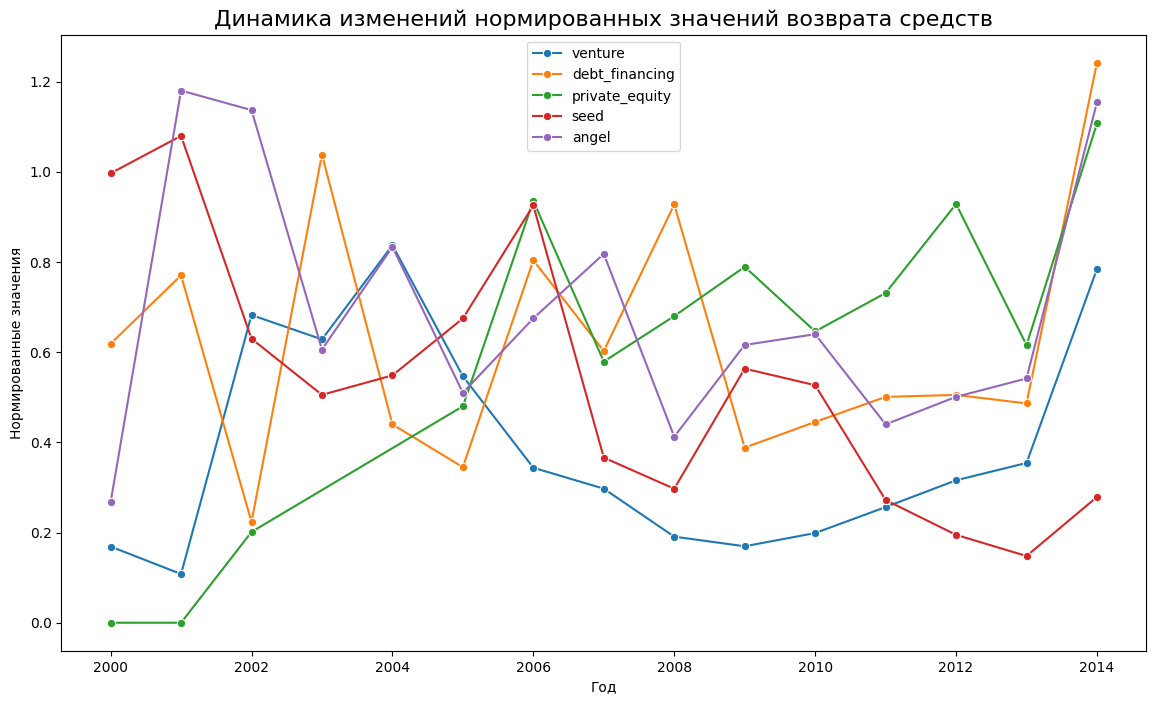

In [100]:
plt.figure(figsize = (14, 8))
for index, column in enumerate(df1.columns):
    
    sns.lineplot(data = df1[column], marker= 'o', label = column )

plt.title(f'Динамика изменений нормированных значений возврата средств', fontsize = 16)
plt.xlabel('Год')
plt.ylabel ('Нормированные значения')
plt.show()

Наиболее устойчивый рост нормированного показателя возврата средств отмечен у сегмента `private_equity` (Прямые частные инвестиции). Сегмент показывает выраженную восходящую тенденцию с 2005 года, последовательно увеличивая показатель возврата к 2014 году, что говорит о растущей эффективности инвестиций в этом сегменте.


## Шаг 5. Итоговый вывод и рекомендации

### Рекомендации на 2015 год:


Для того чтобы минимизировать риски и повысить шансы получения прибыли финансовой компании стоит диверсифицировать свой портфель в разные отрасли. Например можно выбрать наиболее устойчивую отрасль 


Приоритетные отрасли - (**Производство** и **Технологии**): Эти отрасли выделяются как наиболее капиталоемкие, получив максимальный совокупный объем инвестиций за семилетний период. Это свидетельствует об их зрелости и устойчивом высоком интересе со стороны инвесторов.
Перспективные растущие сегменты  - (**Медицина** и **Интернет**): Данные отрасли демонстрируют сильную положительную динамику и последовательный рост. Резкое ускорение финансирования, зафиксированное в 2014 году, указывает на высокий потенциал дальнейшего расширения и масштабирования рынка.

Для отраслей Производство и Технологии наиболее подходящими являются прямые инвестиции (**private_equity**).
Такой выбор обоснован тем, что эти рынки отличаются зрелостью и крупными объемами финансирования. Вложения направлены на масштабирование уже существующего бизнеса, а не на рискованный поиск новых моделей. Дополнительным аргументом в пользу этого типа финансирования является его высокая эффективность, подтвержденная устойчивым ростом нормированного показателя возврата средств.

Для перспективных отраслей, таких как Медицина и Интернет, наилучшим образом подходят **венчурные инвестиции (**venture**).
Обе отрасли продемонстрировали резкий рост финансирования в 2014 году, что указывает на их значительный потенциал. Поскольку эти секторы часто требуют вложений на ранних стадиях и сопряжены с высокими рисками, для них идеально подходит венчурный капитал, который специализируется на инвестировании в молодые, инновационные, высокорискованные компании с расчетом на то, что успешные проекты принесут инвесторам огромную прибыль.

Для минимизации рисков и повышения шансов на получение прибыли финансовой компании стоит диверсифицировать инвестиционный портфель, поэтому оптимальная стратегия заключается в сбалансированном сочетании консервативного и рискованного подходов: рекомендуется выбрать одну из стабильных приоритетных отраслей (Производство и Технологии) и один перспективно растущий сегмент (Медицина и Интернет). 

___
В рамках выполнения проекта была проведена комплексная работа с данными, включающая несколько ключевых этапов:
1. Подготовка и предобработка данных:
Удалены пустые строки и дубликаты.
Преобразованы типы данных в необходимых столбцах.
Пропуски в столбце `mid_funding_at` заполнены средними значениями, а строки с пропусками в `funding_total_usd` — удалены из-за отсутствия важной информации. В результате этих действий размер датасета сократился примерно на 25%.
2. Сегментация и анализ компаний:
Компании были разделены на три категории по срокам финансирования, изучено их количественное и объемное соотношение.
Рынок был разделен на массовый (более 120 компаний), средний и нишевый сегменты. 
3. Анализ аномалий и очистка:
Определен типичный размер финансирования.
С помощью метода IQR выявлены компании с аномальным (чрезмерным) объемом финансирования в разрезе сегментов.
Выделены топ-15 сегментов с наибольшей долей компаний, получивших аномальное финансирование.
Для повышения точности дальнейшего анализа из датасета были исключены компании с аномальным финансированием, а также оставлены только те компании, которые получали финансирование в годы с высокой активностью (более 50 раундов).
4. Анализ финансирования и возвратности инвестиций:
Проведен детальный анализ типов финансирования по популярности, объему и суммарному объему возвратов средств.
Для каждой компании рассчитан средний объем раунда финансирования; изучена динамика типичного размера раунда и их количества по годам.
Составлена и проанализирована сводная таблица по суммарному размеру общего финансирования в разрезе годов и сегментов рынка с добавлением графиков, отражающих динамику с 2008 по 2014 гг.
Рассчитаны и отображены нормированные значения возврата средств для основных типов финансирования (`venture`, `debt_financing`, `private_equity`, `seed`, `angel`).

____
### Краткие выводы по итогам исследования:
1. Сроки финансирования:
Долгосрочное финансирование является основным источником инвестиций по объему средств, привлекая 61,9% от общей суммы, несмотря на меньшее количество компаний по сравнению с единичным финансированием.
Единичное финансирование — самая распространенная модель, охватывающая наибольшее число компаний, но при этом аккумулирующая лишь треть общего объема средств.
2. Сегментация рынка:
Массовые сегменты привлекают основную долю инвестиций и компаний, что говорит о высокой конкуренции и инвестиционной привлекательности.
Нишевые сегменты отличаются высокой степенью фрагментации и специализации, предлагая возможности для уникальных проектов с меньшим числом конкурентов.
2. Выбросы:
Аномально высокие объемы финансирования (свыше 24,5 млн USD) чаще наблюдаются в крупных массовых сегментах, особенно в недвижимости, развлечениях и консалтинге.
В данных за декабрь 2014 года зафиксированы значительные пробелы, что, вероятно, свидетельствует о неполноте сбора информации, однако эти пропуски не должны критически повлиять на итоговый анализ.
3. Типы финансирования:
Венчурное финансирование является абсолютным лидером на рынке инвестиций по обоим основным показателям:
Оно аккумулирует подавляющую часть общего капитала — 80% (129,12 млрд. USD).
Это самый распространенный тип финансирования, составляющий 44,51% от общего числа случаев привлечения средств.
4. Объем и количество раундов финансирования:
В период с 2000 по 2014 годы на инвестиционном рынке наблюдались две противоположные тенденции: устойчивое снижение среднего объема финансирования за раунд (с пика в 2005 году до минимума в 2013–2014 годах) при одновременном непрерывном росте общего количества раундов (с пиком активности в 2013 году). В результате, 2014 год характеризовался высокой частотой инвестиционных сделок при относительно небольшом среднем размере каждого отдельного раунда.
5. Массовые сегменты рынка:
Большинство рассмотренных сегментов демонстрировали устойчивый или ускоряющийся рост объемов финансирования к 2014 году.
Приложения, Медицинские технологии и Стартапы показали наиболее резкий скачок инвестиций в 2014 году, что свидетельствует о взрывном росте интереса к этим областям.
Сегменты SaaS, Дизайн и Интернет демонстрировали стабильный, уверенный и поступательный рост на протяжении второй половины периода. SaaS выделяется как один из наиболее надежных и быстрорастущих сегментов.
Big Data показал замедление и стабилизацию динамики к 2013–2014 годам, несмотря на сильный рост в начале периода.
Производство и Технологии занимают лидирующие позиции по общему объему инвестиций, однако их темпы роста подвержены значительной волатильности.
Недвижимость восстановился после минимума 2011 года и вышел на фазу быстрого роста.
6. Возврат инвестиций
Прямые частные инвестиции показали наиболее устойчивый и выраженный рост нормированного показателя возврата средств с 2005 по 2014 год.

___

Предоставленные выводы в целом хорошо согласуются друг с другом и рисуют непротиворечивую картину инвестиционного рынка в рассматриваемый период (2000–2014 гг.). Они логично дополняют друг друга, объясняя общие тренды рынка и их проявления в конкретных сегментах и типах финансирования.